<a href="https://colab.research.google.com/github/HK25abm/Transformer-Phishing-Detection/blob/main/XAI_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/phishing_project"

print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))
print("Project exists:", os.path.exists(PROJECT_DIR))

MyDrive exists: True
Project exists: True


In [3]:
import os
import gc
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from lime.lime_text import LimeTextExplainer
import shap
from captum.attr import IntegratedGradients

ModuleNotFoundError: No module named 'lime'

In [ ]:
PHASE4_DIR = os.path.join(
    PROJECT_DIR,
    "phase4_xai"
)

os.makedirs(
    PHASE4_DIR,
    exist_ok=True
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)
print("PHASE4_DIR:", PHASE4_DIR)

In [4]:
!pip install -q lime shap captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 25.0 MB/s eta 0:00:00


In [5]:
import lime
import shap
import captum

print("LIME:", lime.__version__)
print("SHAP:", shap.__version__)
print("Captum imported successfully")

AttributeError: module 'lime' has no attribute '__version__'

In [6]:
!pip install -q lime shap captum

In [7]:
import lime
import shap
import captum

print("LIME:", lime.__version__)
print("SHAP:", shap.__version__)
print("Captum imported successfully")

AttributeError: module 'lime' has no attribute '__version__'

In [8]:
from lime.lime_text import LimeTextExplainer
import shap
from captum.attr import IntegratedGradients

print("✓ LIME imported")
print("✓ SHAP imported")
print("✓ Captum imported")
print("SHAP version:", shap.__version__)

✓ LIME imported
✓ SHAP imported
✓ Captum imported
SHAP version: 0.52.0


In [9]:
import os

PROJECT_DIR = "/content/drive/MyDrive/phishing_project"

print("Project exists:", os.path.exists(PROJECT_DIR))

if os.path.exists(PROJECT_DIR):
    print(os.listdir(PROJECT_DIR))

Project exists: True
['validation.csv', 'train.csv', 'test.csv', 'adversarial_testing', 'saved_models', 'phase1_stronger_adversarial_testing', 'phase1_contextual_adversarial', 'deberta_fixed_clean_results.csv', 'results', 'final_phase1_results', 'phase2_adversarial_training', 'final_phase2_results', 'phase4_xai']


In [10]:
Project exists: True
['validation.csv', 'train.csv', 'test.csv', 'adversarial_testing', 'saved_models', 'phase1_stronger_adversarial_testing', 'phase1_contextual_adversarial', 'deberta_fixed_clean_results.csv', 'results', 'final_phase1_results', 'phase2_adversarial_training', 'final_phase2_results', 'phase4_xai']


SyntaxError: invalid syntax (1608105111.py, line 1)

In [11]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("DEVICE:", DEVICE)

DEVICE: cuda


In [12]:
import os

BERT_PATH = os.path.join(
    PROJECT_DIR,
    "final_phase2_results",
    "bert_final_defended"
)

print("BERT path:", BERT_PATH)
print("Exists:", os.path.exists(BERT_PATH))

if os.path.exists(BERT_PATH):
    print(os.listdir(BERT_PATH))

BERT path: /content/drive/MyDrive/phishing_project/final_phase2_results/bert_final_defended
Exists: True
['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'clean_metrics.csv', 'adversarial_metrics.csv', 'robustness_comparison.csv', 'training_time.csv', 'clean_predictions.csv', 'adversarial_predictions.csv', 'clean_confusion_matrix.csv', 'adversarial_confusion_matrix.csv', 'clean_roc.csv', 'adversarial_roc.csv', 'experiment_summary.csv']


In [13]:
import os

BERT_PATH = os.path.join(
    PROJECT_DIR,
    "final_phase2_results",
    "bert_final_defended"
)

print("BERT path:", BERT_PATH)
print("Exists:", os.path.exists(BERT_PATH))

if os.path.exists(BERT_PATH):
    print(os.listdir(BERT_PATH))

BERT path: /content/drive/MyDrive/phishing_project/final_phase2_results/bert_final_defended
Exists: True
['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'clean_metrics.csv', 'adversarial_metrics.csv', 'robustness_comparison.csv', 'training_time.csv', 'clean_predictions.csv', 'adversarial_predictions.csv', 'clean_confusion_matrix.csv', 'adversarial_confusion_matrix.csv', 'clean_roc.csv', 'adversarial_roc.csv', 'experiment_summary.csv']


In [14]:
bert_tokenizer = AutoTokenizer.from_pretrained(
    BERT_PATH,
    local_files_only=True
)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_PATH,
    local_files_only=True,
    torch_dtype=torch.float32
)

bert_model.to(DEVICE)
bert_model.eval()

print("Final defended BERT loaded successfully.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:03<?, ?it/s]

Final defended BERT loaded successfully.


In [15]:
def predict_proba(
    model,
    tokenizer,
    texts,
    batch_size=16,
    max_length=256
):

    model.eval()
    all_probs = []

    with torch.no_grad():

        for start in range(
            0,
            len(texts),
            batch_size
        ):

            batch_texts = texts[
                start:start + batch_size
            ]

            enc = tokenizer(
                list(batch_texts),
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            enc = {
                k: v.to(DEVICE)
                for k, v in enc.items()
            }

            logits = model(
                **enc
            ).logits

            probs = torch.softmax(
                logits.float(),
                dim=1
            )

            all_probs.append(
                probs.cpu().numpy()
            )

            del enc
            del logits
            del probs

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return np.vstack(all_probs)

In [16]:
def bert_predict_proba(texts):
    return predict_proba(
        bert_model,
        bert_tokenizer,
        texts,
        batch_size=16
    )

In [17]:
print(
    bert_predict_proba(
        [
            "Your PayPal account has been suspended. Verify your password immediately.",
            "The meeting has been moved to Tuesday afternoon."
        ]
    )
)

[[6.9837530e-05 9.9993014e-01]
 [9.9997067e-01 2.9330526e-05]]


In [18]:
bert_clean_probs = bert_predict_proba(
    test_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

bert_clean_pred = np.argmax(
    bert_clean_probs,
    axis=1
)

bert_test_eval = test_df.copy()

bert_test_eval["prediction"] = bert_clean_pred
bert_test_eval["phishing_probability"] = bert_clean_probs[:, 1]

NameError: name 'test_df' is not defined

In [19]:
import pandas as pd
import os

test_df = pd.read_csv(
    os.path.join(
        PROJECT_DIR,
        "test.csv"
    )
)

test_df["text"] = (
    test_df["text"]
    .fillna("")
    .astype(str)
)

test_df["label"] = (
    test_df["label"]
    .astype(int)
)

print(test_df.shape)
print(test_df["label"].value_counts())

(3000, 6)
label
0    1500
1    1500
Name: count, dtype: int64


In [20]:
ADV_DIR = os.path.join(
    PROJECT_DIR,
    "phase1_contextual_adversarial"
)

bert_adv = pd.read_csv(
    os.path.join(
        ADV_DIR,
        "bert_contextual_adversarial_results.csv"
    )
)

roberta_adv = pd.read_csv(
    os.path.join(
        ADV_DIR,
        "roberta_contextual_adversarial_results.csv"
    )
)

deberta_adv = pd.read_csv(
    os.path.join(
        ADV_DIR,
        "deberta_contextual_adversarial_results.csv"
    )
)

print("BERT:", bert_adv.shape)
print("RoBERTa:", roberta_adv.shape)
print("DeBERTa:", deberta_adv.shape)

BERT: (300, 10)
RoBERTa: (298, 10)
DeBERTa: (297, 10)


In [21]:
bert_clean_probs = bert_predict_proba(
    test_df["text"]
    .tolist()
)

In [23]:
bert_clean_probs = bert_predict_proba(
    test_df["text"].tolist()
)

bert_clean_pred = np.argmax(
    bert_clean_probs,
    axis=1
)

bert_test_eval = test_df.copy()

bert_test_eval["prediction"] = bert_clean_predbert_tp = bert_test_eval[
    (bert_test_eval["label"] == 1) &
    (bert_test_eval["prediction"] == 1)
]

bert_tn = bert_test_eval[
    (bert_test_eval["label"] == 0) &
    (bert_test_eval["prediction"] == 0)
]

tp_row = (
    bert_tp
    .sort_values(
        "phishing_probability",
        ascending=False
    )
    .iloc[0]
)

tn_row = (
    bert_tn
    .sort_values(
        "phishing_probability",
        ascending=True
    )
    .iloc[0]
)

print("TP:", tp_row["sample_id"])
print("TN:", tn_row["sample_id"])n_probs[:, 1]

SyntaxError: invalid syntax (2173319848.py, line 41)

In [24]:
print("TN:", tn_row["sample_id"])n_probs[:, 1]

SyntaxError: invalid syntax (3522110628.py, line 1)

In [25]:
bert_tp = bert_test_eval[
    (bert_test_eval["label"] == 1) &
    (bert_test_eval["prediction"] == 1)
]

bert_tn = bert_test_eval[
    (bert_test_eval["label"] == 0) &
    (bert_test_eval["prediction"] == 0)
]

tp_row = (
    bert_tp
    .sort_values(
        "phishing_probability",
        ascending=False
    )
    .iloc[0]
)

tn_row = (
    bert_tn
    .sort_values(
        "phishing_probability",
        ascending=True
    )
    .iloc[0]
)

print("TP:", tp_row["sample_id"])
print("TN:", tn_row["sample_id"])

TP: EMAIL_004358
TN: EMAIL_007360


In [26]:
print("TN:", tn_row["sample_id"])

TN: EMAIL_007360


In [27]:
bert_successful_adv = bert_adv[
    bert_adv["successful_evasion"] == True
].copy()

adv_row = (
    bert_successful_adv
    .sort_values(
        "confidence_drop",
        ascending=False
    )
    .iloc[0]
)

print("Adversarial sample:", adv_row["sample_id"])
print("Original probability:", adv_row["original_probability"])
print("Adversarial probability:", adv_row["adversarial_probability"])
print("Semantic similarity:", adv_row["semantic_similarity"])

Adversarial sample: EMAIL_013283
Original probability: 0.999885320663452
Adversarial probability: 0.000119233278383
Semantic similarity: 0.9290109872817992


In [28]:
bert_lime_explainer = LimeTextExplainer(
    class_names=["Legitimate", "Phishing"],
    random_state=42
)

In [29]:
bert_adv_original_exp = bert_lime_explainer.explain_instance(
    adv_row["original_text"],
    bert_predict_proba,
    labels=[1],
    num_features=15,
    num_samples=1000
)

bert_adv_original_features = bert_adv_original_exp.as_list(
    label=1
)

print("ORIGINAL FEATURES:")
print(bert_adv_original_features)

ORIGINAL FEATURES:
[(np.str_('jkoutsi'), 0.13024671137852445), (np.str_('beckyvgko'), 0.12983069923601512), (np.str_('our'), 0.06696061217269202), (np.str_('shareholder'), 0.06320656842305955), (np.str_('anthropomorphism'), 0.056515224956245044), (np.str_('astronaut'), 0.05409662886726719), (np.str_('image'), -0.05364494431577624), (np.str_('information'), -0.05310471897806739), (np.str_('open'), 0.050952453825946244), (np.str_('ryan'), -0.04417470136993822), (np.str_('urgent'), 0.04275930572347705), (np.str_('opera'), 0.04196226969991168), (np.str_('msn'), -0.03901204368857279), (np.str_('if'), -0.0370804510783497), (np.str_('site'), 0.03187379084413715)]


In [30]:
bert_adv_modified_exp = bert_lime_explainer.explain_instance(
    adv_row["adversarial_text"],
    bert_predict_proba,
    labels=[1],
    num_features=15,
    num_samples=1000
)

bert_adv_modified_features = bert_adv_modified_exp.as_list(
    label=1
)

print("ADVERSARIAL FEATURES:")
print(bert_adv_modified_features)

ADVERSARIAL FEATURES:
[(np.str_('image'), -0.36270779494172184), (np.str_('msn'), -0.23568463818695606), (np.str_('information'), -0.21300035046341487), (np.str_('if'), -0.20472132106082666), (np.str_('astronaut'), 0.19950454959286346), (np.str_('shareholder'), 0.1892855393201187), (np.str_('please'), -0.16510545417934722), (np.str_('anthropomorphism'), 0.16169632769167452), (np.str_('above'), -0.14677168906500176), (np.str_('our'), 0.14604409346663308), (np.str_('opera'), 0.13442210287333137), (np.str_('important'), 0.13398914496833822), (np.str_('mobile'), 0.11263969580377362), (np.str_('testate'), 0.1040012271519024), (np.str_('open'), 0.0854961224542656)]


In [31]:
bert_adv_modified_exp = bert_lime_explainer.explain_instance(
    adv_row["adversarial_text"],
    bert_predict_proba,
    labels=[1],
    num_features=15,
    num_samples=1000
)

bert_adv_modified_features = bert_adv_modified_exp.as_list(
    label=1
)

print("ADVERSARIAL FEATURES:")
print(bert_adv_modified_features)

ADVERSARIAL FEATURES:
[(np.str_('image'), -0.2831070312688509), (np.str_('information'), -0.2686112491000032), (np.str_('if'), -0.23052088839344675), (np.str_('astronaut'), 0.21826322003833204), (np.str_('shareholder'), 0.20442267149022658), (np.str_('today'), -0.19647942274632196), (np.str_('anthropomorphism'), 0.17313112548615042), (np.str_('msn'), -0.17032355110090822), (np.str_('our'), 0.1600839246153217), (np.str_('hastings'), -0.15025094641027645), (np.str_('mobile'), 0.12925169734948988), (np.str_('please'), -0.1221187203787947), (np.str_('testate'), 0.11728891147911298), (np.str_('opera'), 0.1131278616660507), (np.str_('important'), 0.09688470020314206)]


In [32]:
BERT_LIME_DIR = os.path.join(
    PHASE4_DIR,
    "bert",
    "lime"
)

os.makedirs(BERT_LIME_DIR, exist_ok=True)

bert_adv_original_exp.save_to_file(
    os.path.join(
        BERT_LIME_DIR,
        "adversarial_original.html"
    )
)

bert_adv_modified_exp.save_to_file(
    os.path.join(
        BERT_LIME_DIR,
        "adversarial_modified.html"
    )
)

pd.DataFrame(
    bert_adv_original_features,
    columns=["feature", "weight"]
).to_csv(
    os.path.join(
        BERT_LIME_DIR,
        "adversarial_original.csv"
    ),
    index=False
)

pd.DataFrame(
    bert_adv_modified_features,
    columns=["feature", "weight"]
).to_csv(
    os.path.join(
        BERT_LIME_DIR,
        "adversarial_modified.csv"
    ),
    index=False
)

NameError: name 'PHASE4_DIR' is not defined

In [33]:
import os

PHASE4_DIR = os.path.join(
    PROJECT_DIR,
    "phase4_xai"
)

os.makedirs(
    PHASE4_DIR,
    exist_ok=True
)

print(PHASE4_DIR)

/content/drive/MyDrive/phishing_project/phase4_xai


In [34]:
BERT_LIME_DIR = os.path.join(
    PHASE4_DIR,
    "bert",
    "lime"
)

os.makedirs(
    BERT_LIME_DIR,
    exist_ok=True
)

print(BERT_LIME_DIR)

/content/drive/MyDrive/phishing_project/phase4_xai/bert/lime


In [35]:
bert_adv_original_exp.save_to_file(
    os.path.join(
        BERT_LIME_DIR,
        "adversarial_original.html"
    )
)

bert_adv_modified_exp.save_to_file(
    os.path.join(
        BERT_LIME_DIR,
        "adversarial_modified.html"
    )
)

pd.DataFrame(
    bert_adv_original_features,
    columns=["feature", "weight"]
).to_csv(
    os.path.join(
        BERT_LIME_DIR,
        "adversarial_original.csv"
    ),
    index=False
)

pd.DataFrame(
    bert_adv_modified_features,
    columns=["feature", "weight"]
).to_csv(
    os.path.join(
        BERT_LIME_DIR,
        "adversarial_modified.csv"
    ),
    index=False
)

print("BERT LIME results saved.")

BERT LIME results saved.


In [36]:
original_df = pd.DataFrame(
    bert_adv_original_features,
    columns=["feature", "original_weight"]
)

modified_df = pd.DataFrame(
    bert_adv_modified_features,
    columns=["feature", "modified_weight"]
)

bert_lime_comparison = pd.merge(
    original_df,
    modified_df,
    on="feature",
    how="outer"
).fillna(0)

bert_lime_comparison["weight_change"] = (
    bert_lime_comparison["modified_weight"] -
    bert_lime_comparison["original_weight"]
)

bert_lime_comparison["abs_change"] = (
    bert_lime_comparison["weight_change"].abs()
)

bert_lime_comparison = bert_lime_comparison.sort_values(
    "abs_change",
    ascending=False
)

display(bert_lime_comparison.head(20))

bert_lime_comparison.to_csv(
    os.path.join(
        BERT_LIME_DIR,
        "original_vs_adversarial_feature_comparison.csv"
    ),
    index=False
)

,feature,original_weight,modified_weight,weight_change,abs_change
5,image,-0.053645,-0.283107,-0.229462,0.229462
7,information,-0.053105,-0.268611,-0.215507,0.215507
19,today,0.000000,-0.196479,-0.196479,0.196479
4,if,-0.037080,-0.230521,-0.193440,0.193440
1,astronaut,0.054097,0.218263,0.164167,0.164167
3,hastings,0.000000,-0.150251,-0.150251,0.150251
16,shareholder,0.063207,0.204423,0.141216,0.141216
10,msn,-0.039012,-0.170324,-0.131312,0.131312
8,jkoutsi,0.130247,0.000000,-0.130247,0.130247
2,beckyvgko,0.129831,0.000000,-0.129831,0.129831


In [37]:
original_df = pd.DataFrame(
    bert_adv_original_features,
    columns=["feature", "original_weight"]
)

modified_df = pd.DataFrame(
    bert_adv_modified_features,
    columns=["feature", "modified_weight"]
)

bert_lime_comparison = pd.merge(
    original_df,
    modified_df,
    on="feature",
    how="outer"
).fillna(0)

bert_lime_comparison["weight_change"] = (
    bert_lime_comparison["modified_weight"] -
    bert_lime_comparison["original_weight"]
)

bert_lime_comparison["abs_change"] = (
    bert_lime_comparison["weight_change"].abs()
)

bert_lime_comparison = bert_lime_comparison.sort_values(
    "abs_change",
    ascending=False
)

display(bert_lime_comparison.head(20))

bert_lime_comparison.to_csv(
    os.path.join(
        BERT_LIME_DIR,
        "original_vs_adversarial_feature_comparison.csv"
    ),
    index=False
)

,feature,original_weight,modified_weight,weight_change,abs_change
5,image,-0.053645,-0.283107,-0.229462,0.229462
7,information,-0.053105,-0.268611,-0.215507,0.215507
19,today,0.000000,-0.196479,-0.196479,0.196479
4,if,-0.037080,-0.230521,-0.193440,0.193440
1,astronaut,0.054097,0.218263,0.164167,0.164167
3,hastings,0.000000,-0.150251,-0.150251,0.150251
16,shareholder,0.063207,0.204423,0.141216,0.141216
10,msn,-0.039012,-0.170324,-0.131312,0.131312
8,jkoutsi,0.130247,0.000000,-0.130247,0.130247
2,beckyvgko,0.129831,0.000000,-0.129831,0.129831


In [38]:
ROBERTA_PATH = os.path.join(
    PROJECT_DIR,
    "final_phase2_results",
    "roberta_final_defended"
)

roberta_tokenizer = AutoTokenizer.from_pretrained(
    ROBERTA_PATH,
    local_files_only=True
)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_PATH,
    local_files_only=True,
    torch_dtype=torch.float32
)

roberta_model.to(DEVICE)
roberta_model.eval()

print("RoBERTa loaded.")

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

RoBERTa loaded.


In [39]:
roberta_clean_probs = roberta_predict_proba(
    test_df["text"].tolist()
)

roberta_clean_pred = np.argmax(
    roberta_clean_probs,
    axis=1
)

roberta_test_eval = test_df.copy()

roberta_test_eval["prediction"] = roberta_clean_pred
roberta_test_eval["phishing_probability"] = roberta_clean_probs[:, 1]

NameError: name 'roberta_predict_proba' is not defined

In [40]:
print(type(roberta_model))
print(type(roberta_tokenizer))

<class 'transformers.models.roberta.modeling_roberta.RobertaForSequenceClassification'>
<class 'transformers.models.roberta.tokenization_roberta.RobertaTokenizer'>


In [41]:
def roberta_predict_proba(texts):
    return predict_proba(
        model=roberta_model,
        tokenizer=roberta_tokenizer,
        texts=texts,
        batch_size=16
    )

In [42]:
print(
    roberta_predict_proba(
        [
            "Your PayPal account has been suspended.",
            "The meeting starts tomorrow."
        ]
    )
)

[[2.3312142e-04 9.9976689e-01]
 [9.9998772e-01 1.2253640e-05]]


In [43]:
roberta_clean_probs = roberta_predict_proba(
    test_df["text"].tolist()
)

roberta_clean_pred = np.argmax(
    roberta_clean_probs,
    axis=1
)

roberta_test_eval = test_df.copy()

roberta_test_eval["prediction"] = roberta_clean_pred
roberta_test_eval["phishing_probability"] = roberta_clean_probs[:, 1]

In [44]:
roberta_tp = roberta_test_eval[
    (roberta_test_eval["label"] == 1) &
    (roberta_test_eval["prediction"] == 1)
]

roberta_tn = roberta_test_eval[
    (roberta_test_eval["label"] == 0) &
    (roberta_test_eval["prediction"] == 0)
]

roberta_tp_row = (
    roberta_tp
    .sort_values(
        "phishing_probability",
        ascending=False
    )
    .iloc[0]
)

roberta_tn_row = (
    roberta_tn
    .sort_values(
        "phishing_probability",
        ascending=True
    )
    .iloc[0]
)

print("RoBERTa TP:", roberta_tp_row["sample_id"])
print("RoBERTa TN:", roberta_tn_row["sample_id"])

RoBERTa TP: EMAIL_000456
RoBERTa TN: EMAIL_009066


In [45]:
roberta_successful_adv = roberta_adv[
    roberta_adv["successful_evasion"] == True
].copy()

roberta_adv_row = (
    roberta_successful_adv
    .sort_values(
        "confidence_drop",
        ascending=False
    )
    .iloc[0]
)

print("Adversarial sample:", roberta_adv_row["sample_id"])
print("Original probability:", roberta_adv_row["original_probability"])
print("Adversarial probability:", roberta_adv_row["adversarial_probability"])
print("Similarity:", roberta_adv_row["semantic_similarity"])

Adversarial sample: EMAIL_001226
Original probability: 0.9999488592147828
Adversarial probability: 0.0002263020724058
Similarity: 0.9213546514511108


In [46]:
roberta_lime_explainer = LimeTextExplainer(
    class_names=[
        "Legitimate",
        "Phishing"
    ],
    random_state=42
)

In [47]:
roberta_adv_original_exp = roberta_lime_explainer.explain_instance(
    roberta_adv_row["original_text"],
    roberta_predict_proba,
    labels=[1],
    num_features=15,
    num_samples=1000
)

roberta_adv_original_features = (
    roberta_adv_original_exp.as_list(label=1)
)

print("ROBERTA ORIGINAL:")
print(roberta_adv_original_features)

ROBERTA ORIGINAL:
[(np.str_('US'), 0.07017942346311966), (np.str_('437capable'), 0.0638672710893216), (np.str_('programme'), -0.05276660438629371), (np.str_('New'), 0.045896931476031196), (np.str_('Zealand'), 0.041422303533021836), (np.str_('the'), -0.03205051965730436), (np.str_('servicesregion'), 0.027532035179094937), (np.str_('with'), 0.026715186292521485), (np.str_('and'), -0.025350722044717416), (np.str_('of'), -0.025268836984214987), (np.str_('from'), -0.02298966766998958), (np.str_('all'), 0.020684059966166915), (np.str_('both'), 0.013371508714966857), (np.str_('space'), 0.013038859628436737), (np.str_('s'), 0.011123286477921506)]


In [48]:
roberta_adv_modified_exp = roberta_lime_explainer.explain_instance(
    roberta_adv_row["adversarial_text"],
    roberta_predict_proba,
    labels=[1],
    num_features=15,
    num_samples=1000
)

roberta_adv_modified_features = (
    roberta_adv_modified_exp.as_list(label=1)
)

print("ROBERTA ADVERSARIAL:")
print(roberta_adv_modified_features)

ROBERTA ADVERSARIAL:
[(np.str_('US'), 0.23542902158522155), (np.str_('437capable'), 0.15807468320196102), (np.str_('programme'), -0.14512099370659312), (np.str_('space'), -0.13174692763369109), (np.str_('servicesregion'), 0.1278247933730996), (np.str_('the'), -0.12514485678253062), (np.str_('Mir'), -0.0965775808790976), (np.str_('and'), 0.08667900361278595), (np.str_('with'), -0.07046576743397137), (np.str_('receiving'), -0.059635617679566745), (np.str_('including'), -0.05674806550886198), (np.str_('involvement'), -0.05302566867667905), (np.str_('content'), -0.04964391794264537), (np.str_('Zealand'), -0.03647672418101888), (np.str_('s'), -0.03158225114284222)]


In [49]:
ROBERTA_LIME_DIR = os.path.join(
    PHASE4_DIR,
    "roberta",
    "lime"
)

os.makedirs(ROBERTA_LIME_DIR, exist_ok=True)

roberta_adv_original_exp.save_to_file(
    os.path.join(
        ROBERTA_LIME_DIR,
        "adversarial_original.html"
    )
)

roberta_adv_modified_exp.save_to_file(
    os.path.join(
        ROBERTA_LIME_DIR,
        "adversarial_modified.html"
    )
)

pd.DataFrame(
    roberta_adv_original_features,
    columns=["feature", "weight"]
).to_csv(
    os.path.join(
        ROBERTA_LIME_DIR,
        "adversarial_original.csv"
    ),
    index=False
)

pd.DataFrame(
    roberta_adv_modified_features,
    columns=["feature", "weight"]
).to_csv(
    os.path.join(
        ROBERTA_LIME_DIR,
        "adversarial_modified.csv"
    ),
    index=False
)

In [50]:
roberta_original_df = pd.DataFrame(
    roberta_adv_original_features,
    columns=["feature", "original_weight"]
)

roberta_modified_df = pd.DataFrame(
    roberta_adv_modified_features,
    columns=["feature", "modified_weight"]
)

roberta_lime_comparison = pd.merge(
    roberta_original_df,
    roberta_modified_df,
    on="feature",
    how="outer"
).fillna(0)

roberta_lime_comparison["weight_change"] = (
    roberta_lime_comparison["modified_weight"]
    - roberta_lime_comparison["original_weight"]
)

roberta_lime_comparison["abs_change"] = (
    roberta_lime_comparison["weight_change"].abs()
)

roberta_lime_comparison = (
    roberta_lime_comparison
    .sort_values(
        "abs_change",
        ascending=False
    )
)

display(
    roberta_lime_comparison.head(20)
)

roberta_lime_comparison.to_csv(
    os.path.join(
        ROBERTA_LIME_DIR,
        "original_vs_adversarial_feature_comparison.csv"
    ),
    index=False
)

,feature,original_weight,modified_weight,weight_change,abs_change
3,US,0.070179,0.235429,0.165250,0.165250
17,space,0.013039,-0.131747,-0.144786,0.144786
6,and,-0.025351,0.086679,0.112030,0.112030
16,servicesregion,0.027532,0.127825,0.100293,0.100293
19,with,0.026715,-0.070466,-0.097181,0.097181
1,Mir,0.000000,-0.096578,-0.096578,0.096578
0,437capable,0.063867,0.158075,0.094207,0.094207
18,the,-0.032051,-0.125145,-0.093094,0.093094
13,programme,-0.052767,-0.145121,-0.092354,0.092354
4,Zealand,0.041422,-0.036477,-0.077899,0.077899


In [51]:
DEBERTA_PATH = os.path.join(
    PROJECT_DIR,
    "final_phase2_results",
    "deberta_final_defended"
)

deberta_tokenizer = AutoTokenizer.from_pretrained(
    DEBERTA_PATH,
    local_files_only=True
)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    DEBERTA_PATH,
    local_files_only=True,
    torch_dtype=torch.float32
)

deberta_model.to(DEVICE)
deberta_model.eval()

print("DeBERTa loaded.")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DeBERTa loaded.


In [52]:
def deberta_predict_proba(texts):
    return predict_proba(
        model=deberta_model,
        tokenizer=deberta_tokenizer,
        texts=texts,
        batch_size=8
    )

In [53]:
print(
    deberta_predict_proba(
        [
            "Your PayPal account has been suspended.",
            "The meeting starts tomorrow."
        ]
    )
)

[[9.6349394e-01 3.6506023e-02]
 [9.9999201e-01 7.9986721e-06]]


In [54]:
deberta_clean_probs = deberta_predict_proba(
    test_df["text"].tolist()
)

deberta_clean_pred = np.argmax(
    deberta_clean_probs,
    axis=1
)

deberta_test_eval = test_df.copy()

deberta_test_eval["prediction"] = deberta_clean_pred
deberta_test_eval["phishing_probability"] = deberta_clean_probs[:, 1]

In [55]:
deberta_tp = deberta_test_eval[
    (deberta_test_eval["label"] == 1) &
    (deberta_test_eval["prediction"] == 1)
]

deberta_tn = deberta_test_eval[
    (deberta_test_eval["label"] == 0) &
    (deberta_test_eval["prediction"] == 0)
]

deberta_tp_row = (
    deberta_tp
    .sort_values(
        "phishing_probability",
        ascending=False
    )
    .iloc[0]
)

deberta_tn_row = (
    deberta_tn
    .sort_values(
        "phishing_probability",
        ascending=True
    )
    .iloc[0]
)

print("DeBERTa TP:", deberta_tp_row["sample_id"])
print("DeBERTa TN:", deberta_tn_row["sample_id"])

DeBERTa TP: EMAIL_008777
DeBERTa TN: EMAIL_011819


In [56]:
deberta_tp = deberta_test_eval[
    (deberta_test_eval["label"] == 1) &
    (deberta_test_eval["prediction"] == 1)
]

deberta_tn = deberta_test_eval[
    (deberta_test_eval["label"] == 0) &
    (deberta_test_eval["prediction"] == 0)
]

deberta_tp_row = (
    deberta_tp
    .sort_values(
        "phishing_probability",
        ascending=False
    )
    .iloc[0]
)

deberta_tn_row = (
    deberta_tn
    .sort_values(
        "phishing_probability",
        ascending=True
    )
    .iloc[0]
)

print("DeBERTa TP:", deberta_tp_row["sample_id"])
print("DeBERTa TN:", deberta_tn_row["sample_id"])

DeBERTa TP: EMAIL_008777
DeBERTa TN: EMAIL_011819


In [57]:
deberta_lime_explainer = LimeTextExplainer(
    class_names=[
        "Legitimate",
        "Phishing"
    ],
    random_state=42
)

In [58]:
deberta_adv_original_exp = (
    deberta_lime_explainer.explain_instance(
        deberta_adv_row["original_text"],
        deberta_predict_proba,
        labels=[1],
        num_features=15,
        num_samples=1000
    )
)

deberta_adv_original_features = (
    deberta_adv_original_exp.as_list(
        label=1
    )
)

print("DEBERTA ORIGINAL:")
print(deberta_adv_original_features)

NameError: name 'deberta_adv_row' is not defined

In [59]:
deberta_successful_adv = deberta_adv[
    deberta_adv["successful_evasion"] == True
].copy()

print(
    "Successful DeBERTa adversarial examples:",
    len(deberta_successful_adv)
)

deberta_adv_row = (
    deberta_successful_adv
    .sort_values(
        "confidence_drop",
        ascending=False
    )
    .iloc[0]
)

print("Adversarial sample:", deberta_adv_row["sample_id"])
print("Original probability:", deberta_adv_row["original_probability"])
print("Adversarial probability:", deberta_adv_row["adversarial_probability"])
print("Similarity:", deberta_adv_row["semantic_similarity"])

Successful DeBERTa adversarial examples: 10
Adversarial sample: EMAIL_006886
Original probability: 0.999955415725708
Adversarial probability: 0.0001232560462085
Similarity: 0.9574034214019777


In [60]:
deberta_lime_explainer = LimeTextExplainer(
    class_names=[
        "Legitimate",
        "Phishing"
    ],
    random_state=42
)

In [61]:
deberta_adv_original_exp = (
    deberta_lime_explainer.explain_instance(
        deberta_adv_row["original_text"],
        deberta_predict_proba,
        labels=[1],
        num_features=15,
        num_samples=1000
    )
)

deberta_adv_original_features = (
    deberta_adv_original_exp.as_list(
        label=1
    )
)

print("DEBERTA ORIGINAL:")
print(deberta_adv_original_features)

DEBERTA ORIGINAL:
[(np.str_('com'), 0.026187825212676378), (np.str_('www'), 0.02519634438025102), (np.str_('http'), 0.023568832121520965), (np.str_('organic'), 0.020194941029229318), (np.str_('Free'), 0.020185109197255843), (np.str_('for'), -0.012971477276997613), (np.str_('risepat'), 0.008699638043625852), (np.str_('growth'), 0.007386758770750213), (np.str_('enhancement'), 0.0034429079702171573), (np.str_('trials'), -0.00018536110678360284), (np.str_('packs'), -0.00017677958117928824)]


In [62]:
deberta_adv_modified_exp = (
    deberta_lime_explainer.explain_instance(
        deberta_adv_row["adversarial_text"],
        deberta_predict_proba,
        labels=[1],
        num_features=15,
        num_samples=1000
    )
)

deberta_adv_modified_features = (
    deberta_adv_modified_exp.as_list(
        label=1
    )
)

print("DEBERTA ADVERSARIAL:")
print(deberta_adv_modified_features)

DEBERTA ADVERSARIAL:
[(np.str_('bloomberg'), -0.7729278185527315), (np.str_('com'), -0.2244779758627123), (np.str_('packs'), -0.13255049150606532), (np.str_('www'), -0.11241710442099352), (np.str_('Free'), 0.1123072990835578), (np.str_('for'), -0.10544179998807104), (np.str_('trials'), 0.08024793248855952), (np.str_('http'), 0.0305688690967701), (np.str_('enhancement'), 0.02191474582694747), (np.str_('organic'), -0.008497049273723968), (np.str_('growth'), -0.0023624747584950548)]


In [63]:
DEBERTA_LIME_DIR = os.path.join(
    PHASE4_DIR,
    "deberta",
    "lime"
)

os.makedirs(
    DEBERTA_LIME_DIR,
    exist_ok=True
)

deberta_adv_original_exp.save_to_file(
    os.path.join(
        DEBERTA_LIME_DIR,
        "adversarial_original.html"
    )
)

deberta_adv_modified_exp.save_to_file(
    os.path.join(
        DEBERTA_LIME_DIR,
        "adversarial_modified.html"
    )
)

pd.DataFrame(
    deberta_adv_original_features,
    columns=["feature", "weight"]
).to_csv(
    os.path.join(
        DEBERTA_LIME_DIR,
        "adversarial_original.csv"
    ),
    index=False
)

pd.DataFrame(
    deberta_adv_modified_features,
    columns=["feature", "weight"]
).to_csv(
    os.path.join(
        DEBERTA_LIME_DIR,
        "adversarial_modified.csv"
    ),
    index=False
)

In [64]:
deberta_original_df = pd.DataFrame(
    deberta_adv_original_features,
    columns=["feature", "original_weight"]
)

deberta_modified_df = pd.DataFrame(
    deberta_adv_modified_features,
    columns=["feature", "modified_weight"]
)

deberta_lime_comparison = pd.merge(
    deberta_original_df,
    deberta_modified_df,
    on="feature",
    how="outer"
).fillna(0)

deberta_lime_comparison["weight_change"] = (
    deberta_lime_comparison["modified_weight"]
    - deberta_lime_comparison["original_weight"]
)

deberta_lime_comparison["abs_change"] = (
    deberta_lime_comparison["weight_change"].abs()
)

deberta_lime_comparison = (
    deberta_lime_comparison
    .sort_values(
        "abs_change",
        ascending=False
    )
)

display(
    deberta_lime_comparison.head(20)
)

deberta_lime_comparison.to_csv(
    os.path.join(
        DEBERTA_LIME_DIR,
        "original_vs_adversarial_feature_comparison.csv"
    ),
    index=False
)

,feature,original_weight,modified_weight,weight_change,abs_change
1,bloomberg,0.000000,-0.772928,-0.772928,0.772928
2,com,0.026188,-0.224478,-0.250666,0.250666
11,www,0.025196,-0.112417,-0.137613,0.137613
8,packs,-0.000177,-0.132550,-0.132374,0.132374
4,for,-0.012971,-0.105442,-0.092470,0.092470
0,Free,0.020185,0.112307,0.092122,0.092122
10,trials,-0.000185,0.080248,0.080433,0.080433
7,organic,0.020195,-0.008497,-0.028692,0.028692
3,enhancement,0.003443,0.021915,0.018472,0.018472
5,growth,0.007387,-0.002362,-0.009749,0.009749


In [65]:
import shap
import numpy as np
import pandas as pd
import os

In [66]:
def bert_shap_predict(texts):

    probs = bert_predict_proba(
        list(texts)
    )

    return probs[:, 1]

In [67]:
print(
    bert_shap_predict(
        [
            "Your account has been suspended. Verify immediately.",
            "The meeting is tomorrow."
        ]
    )
)

[9.9993467e-01 5.8534133e-05]


In [68]:
bert_masker = shap.maskers.Text(
    bert_tokenizer
)

In [69]:
bert_shap_explainer = shap.Explainer(
    bert_shap_predict,
    bert_masker,
    algorithm="partition"
)

print("BERT SHAP explainer ready.")

BERT SHAP explainer ready.


In [70]:
bert_shap_original = bert_shap_explainer(
    [
        adv_row["original_text"]
    ],
    max_evals=300
)

In [71]:
bert_shap_modified = bert_shap_explainer(
    [
        adv_row["adversarial_text"]
    ],
    max_evals=300
)

In [72]:
shap.plots.text(
    bert_shap_original[0]
)

In [73]:
shap.plots.text(
    bert_shap_original[0]
)

In [74]:
shap.plots.text(
    bert_shap_modified[0]
)

In [75]:
original_tokens = bert_shap_original[0].data
original_values = bert_shap_original[0].values

bert_shap_original_df = pd.DataFrame({
    "token": original_tokens,
    "shap_value": original_values
})

display(
    bert_shap_original_df
    .assign(
        abs_shap=lambda x:
        x["shap_value"].abs()
    )
    .sort_values(
        "abs_shap",
        ascending=False
    )
    .head(20)
)

,token,shap_value,abs_shap
18,j,0.199604,0.199604
19,kou,0.199604,0.199604
33,site,0.197386,0.197386
56,ryan,-0.131905,0.131905
48,opera,0.127713,0.127713
40,information,0.079773,0.079773
22,if,-0.064265,0.064265
38,.,0.060071,0.060071
42,shareholder,0.056268,0.056268
8,v,0.053109,0.053109


In [76]:
modified_tokens = bert_shap_modified[0].data
modified_values = bert_shap_modified[0].values

bert_shap_modified_df = pd.DataFrame({
    "token": modified_tokens,
    "shap_value": modified_values
})

display(
    bert_shap_modified_df
    .assign(
        abs_shap=lambda x:
        x["shap_value"].abs()
    )
    .sort_values(
        "abs_shap",
        ascending=False
    )
    .head(20)
)

,token,shap_value,abs_shap
33,urgent,0.043976,0.043976
34,information,-0.036893,0.036893
49,astronaut,0.036829,0.036829
43,ant,-0.026664,0.026664
47,rp,-0.014504,0.014504
31,information,-0.013384,0.013384
50,ryan,-0.012334,0.012334
35,hastings,-0.011669,0.011669
44,hr,0.011106,0.011106
25,to,-0.010630,0.010630


In [77]:
BERT_SHAP_DIR = os.path.join(
    PHASE4_DIR,
    "bert",
    "shap"
)

os.makedirs(
    BERT_SHAP_DIR,
    exist_ok=True
)

In [78]:
bert_shap_original_df.to_csv(
    os.path.join(
        BERT_SHAP_DIR,
        "adversarial_original_shap.csv"
    ),
    index=False
)

In [79]:
bert_shap_modified_df.to_csv(
    os.path.join(
        BERT_SHAP_DIR,
        "adversarial_modified_shap.csv"
    ),
    index=False
)

In [80]:
bert_shap_original_comp = (
    bert_shap_original_df
    .rename(
        columns={
            "shap_value":
            "original_shap"
        }
    )
)

bert_shap_modified_comp = (
    bert_shap_modified_df
    .rename(
        columns={
            "shap_value":
            "modified_shap"
        }
    )
)

bert_shap_comparison = pd.merge(
    bert_shap_original_comp,
    bert_shap_modified_comp,
    on="token",
    how="outer"
).fillna(0)

bert_shap_comparison[
    "shap_change"
] = (
    bert_shap_comparison[
        "modified_shap"
    ]
    -
    bert_shap_comparison[
        "original_shap"
    ]
)

bert_shap_comparison[
    "abs_change"
] = (
    bert_shap_comparison[
        "shap_change"
    ].abs()
)

bert_shap_comparison = (
    bert_shap_comparison
    .sort_values(
        "abs_change",
        ascending=False
    )
)

display(
    bert_shap_comparison.head(20)
)

,token,original_shap,modified_shap,shap_change,abs_change
37,j,0.199604,0.000000,-0.199604,0.199604
39,kou,0.199604,0.000000,-0.199604,0.199604
60,site,0.197386,0.000000,-0.197386,0.197386
54,ryan,-0.131905,-0.012334,0.119571,0.119571
50,opera,0.127713,0.010578,-0.117134,0.117134
35,information,0.079773,-0.036893,-0.116666,0.116666
34,information,0.079773,-0.013384,-0.093157,0.093157
6,.,0.060071,-0.005679,-0.065750,0.065750
28,if,-0.064265,-0.000249,0.064016,0.064016
59,shareholder,0.056268,-0.004138,-0.060406,0.060406


In [81]:
bert_shap_comparison.to_csv(
    os.path.join(
        BERT_SHAP_DIR,
        "original_vs_adversarial_shap_comparison.csv"
    ),
    index=False
)

In [82]:
import re
import pandas as pd

def clean_shap_tokens(shap_df):

    df = shap_df.copy()

    df["token"] = (
        df["token"]
        .astype(str)
        .str.strip()
    )

    # Remove obvious empty/special tokens
    df = df[
        ~df["token"].isin([
            "",
            "[CLS]",
            "[SEP]",
            "[PAD]"
        ])
    ].copy()

    # Aggregate identical tokens
    df = (
        df.groupby(
            "token",
            as_index=False
        )["shap_value"]
        .sum()
    )

    df["abs_shap"] = (
        df["shap_value"]
        .abs()
    )

    return (
        df.sort_values(
            "abs_shap",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [83]:
bert_shap_clean_comparison = pd.merge(
    bert_shap_original_clean[
        ["token", "shap_value"]
    ].rename(
        columns={
            "shap_value":
            "original_shap"
        }
    ),

    bert_shap_modified_clean[
        ["token", "shap_value"]
    ].rename(
        columns={
            "shap_value":
            "modified_shap"
        }
    ),

    on="token",
    how="outer"
).fillna(0)

bert_shap_clean_comparison[
    "shap_change"
] = (
    bert_shap_clean_comparison[
        "modified_shap"
    ]
    -
    bert_shap_clean_comparison[
        "original_shap"
    ]
)

bert_shap_clean_comparison[
    "abs_change"
] = (
    bert_shap_clean_comparison[
        "shap_change"
    ].abs()
)

bert_shap_clean_comparison = (
    bert_shap_clean_comparison
    .sort_values(
        "abs_change",
        ascending=False
    )
)

display(
    bert_shap_clean_comparison.head(20)
)

NameError: name 'bert_shap_original_clean' is not defined

In [84]:
def clean_shap_tokens(shap_df):

    df = shap_df.copy()

    df["token"] = (
        df["token"]
        .astype(str)
        .str.strip()
    )

    df = df[
        ~df["token"].isin([
            "",
            "[CLS]",
            "[SEP]",
            "[PAD]"
        ])
    ]

    df = (
        df.groupby(
            "token",
            as_index=False
        )["shap_value"]
        .sum()
    )

    df["abs_shap"] = df["shap_value"].abs()

    return df.sort_values(
        "abs_shap",
        ascending=False
    )

In [85]:
bert_shap_original_clean = clean_shap_tokens(
    bert_shap_original_df
)

bert_shap_modified_clean = clean_shap_tokens(
    bert_shap_modified_df
)

display(bert_shap_original_clean.head(15))
display(bert_shap_modified_clean.head(15))

,token,shap_value,abs_shap
29,j,0.199604,0.199604
31,kou,0.199604,0.199604
48,site,0.197386,0.197386
45,ryan,-0.131905,0.131905
41,opera,0.127713,0.127713
27,information,0.075161,0.075161
24,if,-0.064265,0.064265
2,.,0.060071,0.060071
47,shareholder,0.056268,0.056268
54,v,0.053109,0.053109


,token,shap_value,abs_shap
24,information,-0.050277,0.050277
47,urgent,0.043976,0.043976
11,astronaut,0.036829,0.036829
10,ant,-0.026664,0.026664
39,rp,-0.014504,0.014504
40,ryan,-0.012334,0.012334
17,hastings,-0.011669,0.011669
20,hr,0.011106,0.011106
45,to,-0.010630,0.010630
36,opera,0.010578,0.010578


In [86]:
BERT_SHAP_DIR = os.path.join(
    PHASE4_DIR,
    "bert",
    "shap"
)

os.makedirs(
    BERT_SHAP_DIR,
    exist_ok=True
)

bert_shap_original_clean.to_csv(
    os.path.join(
        BERT_SHAP_DIR,
        "bert_original_shap_clean.csv"
    ),
    index=False
)

bert_shap_modified_clean.to_csv(
    os.path.join(
        BERT_SHAP_DIR,
        "bert_modified_shap_clean.csv"
    ),
    index=False
)

In [87]:
from captum.attr import LayerIntegratedGradients

In [88]:
from captum.attr import LayerIntegratedGradients

In [89]:
from captum.attr import LayerIntegratedGradients

In [90]:
def bert_forward_func(
    input_ids,
    attention_mask
):
    outputs = bert_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    logits = outputs.logits

    probs = torch.softmax(
        logits,
        dim=1
    )

    return probs[:, 1]

In [91]:
bert_lig = LayerIntegratedGradients(
    bert_forward_func,
    bert_model.bert.embeddings
)

print("BERT Integrated Gradients ready.")

BERT Integrated Gradients ready.


In [92]:
def get_bert_ig_attributions(
    text,
    n_steps=50,
    max_length=256
):

    encoded = bert_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    input_ids = encoded[
        "input_ids"
    ].to(DEVICE)

    attention_mask = encoded[
        "attention_mask"
    ].to(DEVICE)

    baseline_ids = torch.full_like(
        input_ids,
        bert_tokenizer.pad_token_id
    )

    attributions, delta = bert_lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(
            attention_mask,
        ),
        n_steps=n_steps,
        return_convergence_delta=True
    )

    token_scores = (
        attributions
        .sum(dim=-1)
        .squeeze(0)
    )

    token_scores = (
        token_scores
        /
        (
            torch.norm(token_scores)
            + 1e-10
        )
    )

    tokens = (
        bert_tokenizer
        .convert_ids_to_tokens(
            input_ids.squeeze(0)
        )
    )

    ig_df = pd.DataFrame({
        "token": tokens,
        "ig_score":
            token_scores
            .detach()
            .cpu()
            .numpy()
    })

    convergence_delta = float(
        delta
        .detach()
        .cpu()
        .mean()
    )

    return (
        ig_df,
        convergence_delta
    )

In [93]:
bert_ig_original_df, \
bert_ig_original_delta = (
    get_bert_ig_attributions(
        adv_row[
            "original_text"
        ]
    )
)

print(
    "Original convergence delta:",
    bert_ig_original_delta
)

Original convergence delta: 0.00013896747259423137


In [94]:
bert_ig_original_ranked = (
    bert_ig_original_df
    .assign(
        abs_ig=lambda x:
        x["ig_score"].abs()
    )
    .sort_values(
        "abs_ig",
        ascending=False
    )
)

display(
    bert_ig_original_ranked.head(20)
)

,token,ig_score,abs_ig
58,[SEP],0.963264,0.963264
0,[CLS],0.115083,0.115083
4,',0.070679,0.070679
56,ryan,0.064794,0.064794
42,shareholder,0.059514,0.059514
33,site,0.056604,0.056604
55,astronaut,0.053571,0.053571
29,please,0.052023,0.052023
15,on,0.049564,0.049564
50,##hr,-0.046248,0.046248


In [95]:
bert_ig_modified_df, \
bert_ig_modified_delta = (
    get_bert_ig_attributions(
        adv_row[
            "adversarial_text"
        ]
    )
)

print(
    "Modified convergence delta:",
    bert_ig_modified_delta
)

Modified convergence delta: 0.018133819103240967


In [96]:
bert_ig_modified_ranked = (
    bert_ig_modified_df
    .assign(
        abs_ig=lambda x:
        x["ig_score"].abs()
    )
    .sort_values(
        "abs_ig",
        ascending=False
    )
)

display(
    bert_ig_modified_ranked.head(20)
)

,token,ig_score,abs_ig
36,shareholder,0.726981,0.726981
35,hastings,-0.423064,0.423064
7,mobile,0.222694,0.222694
18,image,-0.194856,0.194856
27,image,-0.176258,0.176258
23,please,-0.169727,0.169727
48,##hism,-0.140080,0.140080
6,me,-0.100421,0.100421
50,ryan,-0.100318,0.100318
14,##n,-0.098625,0.098625


In [97]:
SPECIAL_TOKENS = {
    "[CLS]",
    "[SEP]",
    "[PAD]"
}

bert_ig_original_clean = (
    bert_ig_original_df[
        ~bert_ig_original_df[
            "token"
        ].isin(
            SPECIAL_TOKENS
        )
    ]
    .copy()
)

bert_ig_modified_clean = (
    bert_ig_modified_df[
        ~bert_ig_modified_df[
            "token"
        ].isin(
            SPECIAL_TOKENS
        )
    ]
    .copy()
)

In [98]:
bert_ig_original_comp = (
    bert_ig_original_clean
    .groupby(
        "token",
        as_index=False
    )["ig_score"]
    .sum()
    .rename(
        columns={
            "ig_score":
            "original_ig"
        }
    )
)

bert_ig_modified_comp = (
    bert_ig_modified_clean
    .groupby(
        "token",
        as_index=False
    )["ig_score"]
    .sum()
    .rename(
        columns={
            "ig_score":
            "modified_ig"
        }
    )
)

bert_ig_comparison = pd.merge(
    bert_ig_original_comp,
    bert_ig_modified_comp,
    on="token",
    how="outer"
).fillna(0)

bert_ig_comparison[
    "ig_change"
] = (
    bert_ig_comparison[
        "modified_ig"
    ]
    -
    bert_ig_comparison[
        "original_ig"
    ]
)

bert_ig_comparison[
    "abs_change"
] = (
    bert_ig_comparison[
        "ig_change"
    ].abs()
)

bert_ig_comparison = (
    bert_ig_comparison
    .sort_values(
        "abs_change",
        ascending=False
    )
)

display(
    bert_ig_comparison.head(20)
)

,token,original_ig,modified_ig,ig_change,abs_change
51,shareholder,0.059514,0.726981,0.667467,0.667467
32,hastings,-0.003887,-0.423064,-0.419178,0.419178
35,image,0.032171,-0.371114,-0.403285,0.403285
41,mobile,0.000000,0.222694,0.222694,0.222694
48,please,0.052023,-0.169727,-0.221750,0.221750
49,ryan,0.064794,-0.100318,-0.165112,0.165112
40,me,0.034949,-0.100421,-0.135371,0.135371
47,our,0.028894,-0.096947,-0.125841,0.125841
46,opera,0.025872,-0.096216,-0.122088,0.122088
54,the,0.027184,-0.093162,-0.120346,0.120346


In [99]:
BERT_IG_DIR = os.path.join(
    PHASE4_DIR,
    "bert",
    "integrated_gradients"
)

os.makedirs(
    BERT_IG_DIR,
    exist_ok=True
)

In [100]:
ig_delta_summary = pd.DataFrame([
    {
        "condition": "Original",
        "convergence_delta": bert_ig_original_delta
    },
    {
        "condition": "Adversarial",
        "convergence_delta": bert_ig_modified_delta
    }
])

ig_delta_summary.to_csv(
    os.path.join(
        BERT_IG_DIR,
        "convergence_delta.csv"
    ),
    index=False
)

display(ig_delta_summary)

,condition,convergence_delta
0,Original,0.000139
1,Adversarial,0.018134


In [101]:
from captum.attr import LayerIntegratedGradients

In [102]:
def roberta_forward_func(
    input_ids,
    attention_mask
):
    outputs = roberta_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    logits = outputs.logits

    probs = torch.softmax(
        logits,
        dim=1
    )

    return probs[:, 1]

In [103]:
roberta_lig = LayerIntegratedGradients(
    roberta_forward_func,
    roberta_model.roberta.embeddings
)

print("RoBERTa Integrated Gradients ready.")

RoBERTa Integrated Gradients ready.


In [104]:
def get_roberta_ig_attributions(
    text,
    n_steps=50,
    max_length=256
):

    encoded = roberta_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    input_ids = encoded[
        "input_ids"
    ].to(DEVICE)

    attention_mask = encoded[
        "attention_mask"
    ].to(DEVICE)

    baseline_ids = torch.full_like(
        input_ids,
        roberta_tokenizer.pad_token_id
    )

    attributions, delta = roberta_lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(
            attention_mask,
        ),
        n_steps=n_steps,
        return_convergence_delta=True
    )

    token_scores = (
        attributions
        .sum(dim=-1)
        .squeeze(0)
    )

    token_scores = (
        token_scores
        /
        (
            torch.norm(token_scores)
            + 1e-10
        )
    )

    tokens = (
        roberta_tokenizer
        .convert_ids_to_tokens(
            input_ids.squeeze(0)
        )
    )

    ig_df = pd.DataFrame({
        "token": tokens,
        "ig_score":
            token_scores
            .detach()
            .cpu()
            .numpy()
    })

    convergence_delta = float(
        delta
        .detach()
        .cpu()
        .mean()
    )

    return (
        ig_df,
        convergence_delta
    )

In [105]:
roberta_ig_original_df, \
roberta_ig_original_delta = (
    get_roberta_ig_attributions(
        roberta_adv_row[
            "original_text"
        ]
    )
)

print(
    "Original convergence delta:",
    roberta_ig_original_delta
)

display(
    roberta_ig_original_df
    .assign(
        abs_ig=lambda x:
        x["ig_score"].abs()
    )
    .sort_values(
        "abs_ig",
        ascending=False
    )
    .head(20)
)

Original convergence delta: 0.15360122919082642


,token,ig_score,abs_ig
0,<s>,0.996126,0.996126
10,Ġ4,-0.028270,0.028270
2,me,0.027754,0.027754
13,able,-0.026812,0.026812
14,Ġof,-0.025650,0.025650
28,Ġleadership,0.024761,0.024761
4,Ġfrom,-0.023190,0.023190
12,cap,-0.020330,0.020330
26,ĠZealand,0.019959,0.019959
32,Ġand,-0.017271,0.017271


In [106]:
def roberta_forward_func(
    input_ids,
    attention_mask
):
    outputs = roberta_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    # phishing class logit
    return outputs.logits[:, 1]

In [107]:
from captum.attr import LayerIntegratedGradients

roberta_lig = LayerIntegratedGradients(
    roberta_forward_func,
    roberta_model.roberta.embeddings.word_embeddings
)

print("Corrected RoBERTa IG ready.")

Corrected RoBERTa IG ready.


In [108]:
def get_roberta_ig_attributions(
    text,
    n_steps=100,
    max_length=256
):

    encoded = roberta_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    # Start baseline with PAD tokens
    baseline_ids = torch.full_like(
        input_ids,
        roberta_tokenizer.pad_token_id
    )

    # Preserve RoBERTa special boundary tokens
    baseline_ids[:, 0] = input_ids[:, 0]

    seq_len = int(attention_mask.sum().item())

    if seq_len > 1:
        baseline_ids[:, seq_len - 1] = input_ids[:, seq_len - 1]

    attributions, delta = roberta_lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(
            attention_mask,
        ),
        n_steps=n_steps,
        return_convergence_delta=True
    )

    token_scores = (
        attributions
        .sum(dim=-1)
        .squeeze(0)
    )

    # Normalize only for presentation
    token_scores = token_scores / (
        torch.norm(token_scores) + 1e-10
    )

    tokens = roberta_tokenizer.convert_ids_to_tokens(
        input_ids.squeeze(0)
    )

    result_df = pd.DataFrame({
        "token": tokens,
        "ig_score": token_scores.detach().cpu().numpy()
    })

    convergence_delta = float(
        delta.detach().cpu().mean()
    )

    return result_df, convergence_delta

In [109]:
roberta_ig_original_df, roberta_ig_original_delta = (
    get_roberta_ig_attributions(
        roberta_adv_row["original_text"],
        n_steps=100
    )
)

print(
    "Original convergence delta:",
    roberta_ig_original_delta
)

display(
    roberta_ig_original_df
    .assign(
        abs_ig=lambda x:
        x["ig_score"].abs()
    )
    .sort_values(
        "abs_ig",
        ascending=False
    )
    .head(20)
)

Original convergence delta: 0.8478212356567383


,token,ig_score,abs_ig
32,Ġand,0.670371,0.670371
1,program,-0.284715,0.284715
2,me,0.279288,0.279288
31,ĠUS,0.243334,0.243334
11,37,0.180787,0.180787
14,Ġof,0.180704,0.180704
6,ĠMir,-0.178082,0.178082
19,Ġcontent,0.163851,0.163851
17,Ġof,0.143841,0.143841
3,Ġreturned,-0.141608,0.141608


In [110]:
roberta_ig_modified_df, roberta_ig_modified_delta = (
    get_roberta_ig_attributions(
        roberta_adv_row["adversarial_text"],
        n_steps=100
    )
)

print(
    "Modified convergence delta:",
    roberta_ig_modified_delta
)

display(
    roberta_ig_modified_df
    .assign(
        abs_ig=lambda x:
        x["ig_score"].abs()
    )
    .sort_values(
        "abs_ig",
        ascending=False
    )
    .head(20)
)

Modified convergence delta: 0.8563473224639893


,token,ig_score,abs_ig
9,Ġwith,0.460938,0.460938
12,cap,-0.362457,0.362457
10,Ġ4,-0.346440,0.346440
32,Ġand,0.333434,0.333434
6,ĠMir,-0.313427,0.313427
11,37,0.227737,0.227737
25,ĠNew,-0.206920,0.206920
23,region,0.192929,0.192929
15,Ġreceiving,-0.179136,0.179136
28,Ġinvolvement,-0.172702,0.172702


In [111]:
from captum.attr import LayerIntegratedGradients

def deberta_forward_func(
    input_ids,
    attention_mask
):
    outputs = deberta_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    return outputs.logits[:, 1]

In [112]:
deberta_lig = LayerIntegratedGradients(
    deberta_forward_func,
    deberta_model.deberta.embeddings.word_embeddings
)

print("DeBERTa Integrated Gradients ready.")

DeBERTa Integrated Gradients ready.


In [113]:
def get_deberta_ig_attributions(
    text,
    n_steps=100,
    max_length=256
):

    encoded = deberta_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    baseline_ids = torch.full_like(
        input_ids,
        deberta_tokenizer.pad_token_id
    )

    # Preserve boundary tokens
    baseline_ids[:, 0] = input_ids[:, 0]

    seq_len = int(attention_mask.sum().item())

    if seq_len > 1:
        baseline_ids[:, seq_len - 1] = input_ids[:, seq_len - 1]

    attributions, delta = deberta_lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(attention_mask,),
        n_steps=n_steps,
        return_convergence_delta=True
    )

    token_scores = (
        attributions
        .sum(dim=-1)
        .squeeze(0)
    )

    token_scores = token_scores / (
        torch.norm(token_scores) + 1e-10
    )

    tokens = deberta_tokenizer.convert_ids_to_tokens(
        input_ids.squeeze(0)
    )

    ig_df = pd.DataFrame({
        "token": tokens,
        "ig_score": token_scores.detach().cpu().numpy()
    })

    convergence_delta = float(
        delta.detach().cpu().mean()
    )

    return ig_df, convergence_delta

In [114]:
deberta_ig_original_df, deberta_ig_original_delta = (
    get_deberta_ig_attributions(
        deberta_adv_row["original_text"]
    )
)

print(
    "Original convergence delta:",
    deberta_ig_original_delta
)

display(
    deberta_ig_original_df
    .assign(
        abs_ig=lambda x: x["ig_score"].abs()
    )
    .sort_values(
        "abs_ig",
        ascending=False
    )
    .head(20)
)

Original convergence delta: -0.03983187675476074


,token,ig_score,abs_ig
13,.,0.489688,0.489688
16,.,0.433413,0.433413
7,▁packs,0.310038,0.310038
4,▁organic,0.264460,0.264460
5,▁growth,0.255201,0.255201
3,▁for,0.252074,0.252074
9,:,0.251838,0.251838
8,▁http,0.204494,0.204494
17,com,0.178717,0.178717
2,▁trials,0.176456,0.176456


In [115]:
deberta_ig_modified_df, deberta_ig_modified_delta = (
    get_deberta_ig_attributions(
        deberta_adv_row["adversarial_text"]
    )
)

print(
    "Modified convergence delta:",
    deberta_ig_modified_delta
)

display(
    deberta_ig_modified_df
    .assign(
        abs_ig=lambda x: x["ig_score"].abs()
    )
    .sort_values(
        "abs_ig",
        ascending=False
    )
    .head(20)
)

Modified convergence delta: 0.024934768676757812


,token,ig_score,abs_ig
14,bloom,-0.805544,0.805544
5,▁growth,-0.318681,0.318681
17,com,-0.217720,0.217720
12,www,-0.203953,0.203953
8,▁http,-0.201660,0.201660
1,▁Free,-0.186216,0.186216
13,.,-0.151138,0.151138
4,▁organic,-0.148503,0.148503
2,▁trials,-0.141096,0.141096
9,:,-0.076692,0.076692


In [116]:
deberta_ig_original_df, deberta_ig_original_delta = (
    get_deberta_ig_attributions(
        deberta_adv_row["original_text"]
    )
)

print(
    "Original convergence delta:",
    deberta_ig_original_delta
)

display(
    deberta_ig_original_df
    .assign(
        abs_ig=lambda x:
        x["ig_score"].abs()
    )
    .sort_values(
        "abs_ig",
        ascending=False
    )
    .head(20)
)

Original convergence delta: -0.03983187675476074


,token,ig_score,abs_ig
13,.,0.489688,0.489688
16,.,0.433413,0.433413
7,▁packs,0.310038,0.310038
4,▁organic,0.264460,0.264460
5,▁growth,0.255201,0.255201
3,▁for,0.252074,0.252074
9,:,0.251838,0.251838
8,▁http,0.204494,0.204494
17,com,0.178717,0.178717
2,▁trials,0.176456,0.176456


In [117]:
DEBERTA_SPECIAL_TOKENS = {
    "[CLS]",
    "[SEP]",
    "[PAD]"
}

deberta_ig_original_clean = (
    deberta_ig_original_df[
        ~deberta_ig_original_df["token"].isin(
            DEBERTA_SPECIAL_TOKENS
        )
    ]
    .copy()
)

deberta_ig_modified_clean = (
    deberta_ig_modified_df[
        ~deberta_ig_modified_df["token"].isin(
            DEBERTA_SPECIAL_TOKENS
        )
    ]
    .copy()
)

deberta_original_comp = (
    deberta_ig_original_clean
    .groupby(
        "token",
        as_index=False
    )["ig_score"]
    .sum()
    .rename(
        columns={
            "ig_score": "original_ig"
        }
    )
)

deberta_modified_comp = (
    deberta_ig_modified_clean
    .groupby(
        "token",
        as_index=False
    )["ig_score"]
    .sum()
    .rename(
        columns={
            "ig_score": "modified_ig"
        }
    )
)

deberta_ig_comparison = pd.merge(
    deberta_original_comp,
    deberta_modified_comp,
    on="token",
    how="outer"
).fillna(0)

deberta_ig_comparison["ig_change"] = (
    deberta_ig_comparison["modified_ig"]
    -
    deberta_ig_comparison["original_ig"]
)

deberta_ig_comparison["abs_change"] = (
    deberta_ig_comparison["ig_change"].abs()
)

deberta_ig_comparison = (
    deberta_ig_comparison
    .sort_values(
        "abs_change",
        ascending=False
    )
)

display(
    deberta_ig_comparison.head(20)
)

,token,original_ig,modified_ig,ig_change,abs_change
0,.,0.923102,-0.197970,-1.121072,1.121072
4,bloom,0.000000,-0.805544,-0.805544,0.805544
12,▁growth,0.255201,-0.318681,-0.573883,0.573883
14,▁organic,0.264460,-0.148503,-0.412963,0.412963
13,▁http,0.204494,-0.201660,-0.406155,0.406155
5,com,0.178717,-0.217720,-0.396437,0.396437
8,www,0.156724,-0.203953,-0.360678,0.360678
2,:,0.251838,-0.076692,-0.328530,0.328530
16,▁trials,0.176456,-0.141096,-0.317552,0.317552
15,▁packs,0.310038,-0.007423,-0.317461,0.317461


In [118]:
DEBERTA_IG_DIR = os.path.join(
    PHASE4_DIR,
    "deberta",
    "integrated_gradients"
)

os.makedirs(DEBERTA_IG_DIR, exist_ok=True)

deberta_ig_original_clean.to_csv(
    os.path.join(
        DEBERTA_IG_DIR,
        "original_ig.csv"
    ),
    index=False
)

deberta_ig_modified_clean.to_csv(
    os.path.join(
        DEBERTA_IG_DIR,
        "adversarial_ig.csv"
    ),
    index=False
)

deberta_ig_comparison.to_csv(
    os.path.join(
        DEBERTA_IG_DIR,
        "original_vs_adversarial_ig.csv"
    ),
    index=False
)

deberta_ig_delta_summary = pd.DataFrame([
    {
        "condition": "Original",
        "convergence_delta": deberta_ig_original_delta
    },
    {
        "condition": "Adversarial",
        "convergence_delta": deberta_ig_modified_delta
    }
])

deberta_ig_delta_summary.to_csv(
    os.path.join(
        DEBERTA_IG_DIR,
        "convergence_delta.csv"
    ),
    index=False
)

print("DeBERTa IG results saved.")

DeBERTa IG results saved.


In [119]:
import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/phishing_project"

PHASE4_DIR = os.path.join(
    PROJECT_DIR,
    "phase4_xai"
)

FINAL_XAI_DIR = os.path.join(
    PHASE4_DIR,
    "final_summary"
)

os.makedirs(
    FINAL_XAI_DIR,
    exist_ok=True
)

print("Final XAI folder:")
print(FINAL_XAI_DIR)

Final XAI folder:
/content/drive/MyDrive/phishing_project/phase4_xai/final_summary


In [120]:
folders_to_check = {
    "BERT LIME":
        os.path.join(PHASE4_DIR, "bert", "lime"),

    "BERT SHAP":
        os.path.join(PHASE4_DIR, "bert", "shap"),

    "BERT IG":
        os.path.join(
            PHASE4_DIR,
            "bert",
            "integrated_gradients"
        ),

    "RoBERTa LIME":
        os.path.join(PHASE4_DIR, "roberta", "lime"),

    "RoBERTa IG":
        os.path.join(
            PHASE4_DIR,
            "roberta",
            "integrated_gradients"
        ),

    "DeBERTa LIME":
        os.path.join(PHASE4_DIR, "deberta", "lime"),

    "DeBERTa IG":
        os.path.join(
            PHASE4_DIR,
            "deberta",
            "integrated_gradients"
        )
}

for name, path in folders_to_check.items():

    print(
        name,
        "->",
        os.path.exists(path)
    )

BERT LIME -> True
BERT SHAP -> True
BERT IG -> True
RoBERTa LIME -> True
RoBERTa IG -> False
DeBERTa LIME -> True
DeBERTa IG -> True


In [121]:
xai_summary = pd.DataFrame([
    {
        "model": "BERT",
        "LIME": "Completed",
        "SHAP": "Completed",
        "Integrated_Gradients": "Completed",
        "IG_status": "Stable",
        "main_finding":
            "Adversarial modification redistributed feature attribution and reversed several feature contributions."
    },

    {
        "model": "RoBERTa",
        "LIME": "Completed",
        "SHAP": "Not used for final cross-model analysis",
        "Integrated_Gradients": "Evaluated",
        "IG_status":
            "Unstable convergence; qualitative interpretation excluded",
        "main_finding":
            "LIME showed substantial redistribution and polarity changes after adversarial modification."
    },

    {
        "model": "DeBERTa",
        "LIME": "Completed",
        "SHAP": "Not used for final cross-model analysis",
        "Integrated_Gradients": "Completed",
        "IG_status": "Stable",
        "main_finding":
            "Adversarial modification produced strong feature polarity reversal, especially for URL-related tokens."
    }
])

display(xai_summary)

,model,LIME,SHAP,Integrated_Gradients,IG_status,main_finding
0,BERT,Completed,Completed,Completed,Stable,Adversarial modification redistributed feature...
1,RoBERTa,Completed,Not used for final cross-model analysis,Evaluated,Unstable convergence; qualitative interpretati...,LIME showed substantial redistribution and pol...
2,DeBERTa,Completed,Not used for final cross-model analysis,Completed,Stable,Adversarial modification produced strong featu...


In [122]:
xai_summary.to_csv(
    os.path.join(
        FINAL_XAI_DIR,
        "final_xai_method_summary.csv"
    ),
    index=False
)

print("XAI method summary saved.")

XAI method summary saved.


In [123]:
ig_convergence_summary = pd.DataFrame([
    {
        "model": "BERT",
        "condition": "Original",
        "convergence_delta": 0.000139,
        "assessment": "Stable"
    },
    {
        "model": "BERT",
        "condition": "Adversarial",
        "convergence_delta": 0.018134,
        "assessment": "Stable"
    },

    {
        "model": "RoBERTa",
        "condition": "Original",
        "convergence_delta": 0.847821,
        "assessment": "Unstable"
    },
    {
        "model": "RoBERTa",
        "condition": "Adversarial",
        "convergence_delta": 0.856347,
        "assessment": "Unstable"
    },

    {
        "model": "DeBERTa",
        "condition": "Original",
        "convergence_delta":
            deberta_ig_original_delta,
        "assessment": "Stable"
    },
    {
        "model": "DeBERTa",
        "condition": "Adversarial",
        "convergence_delta": 0.024934768676757812,
        "assessment": "Stable"
    }
])

display(
    ig_convergence_summary.round(6)
)

,model,condition,convergence_delta,assessment
0,BERT,Original,0.000139,Stable
1,BERT,Adversarial,0.018134,Stable
2,RoBERTa,Original,0.847821,Unstable
3,RoBERTa,Adversarial,0.856347,Unstable
4,DeBERTa,Original,-0.039832,Stable
5,DeBERTa,Adversarial,0.024935,Stable


In [124]:
ig_convergence_summary = pd.DataFrame([
    {
        "model": "BERT",
        "condition": "Original",
        "convergence_delta": 0.000139,
        "assessment": "Stable"
    },
    {
        "model": "BERT",
        "condition": "Adversarial",
        "convergence_delta": 0.018134,
        "assessment": "Stable"
    },

    {
        "model": "RoBERTa",
        "condition": "Original",
        "convergence_delta": 0.847821,
        "assessment": "Unstable"
    },
    {
        "model": "RoBERTa",
        "condition": "Adversarial",
        "convergence_delta": 0.856347,
        "assessment": "Unstable"
    },

    {
        "model": "DeBERTa",
        "condition": "Original",
        "convergence_delta":
            deberta_ig_original_delta,
        "assessment": "Stable"
    },
    {
        "model": "DeBERTa",
        "condition": "Adversarial",
        "convergence_delta": 0.024934768676757812,
        "assessment": "Stable"
    }
])

display(
    ig_convergence_summary.round(6)
)

,model,condition,convergence_delta,assessment
0,BERT,Original,0.000139,Stable
1,BERT,Adversarial,0.018134,Stable
2,RoBERTa,Original,0.847821,Unstable
3,RoBERTa,Adversarial,0.856347,Unstable
4,DeBERTa,Original,-0.039832,Stable
5,DeBERTa,Adversarial,0.024935,Stable


In [125]:
ig_convergence_summary.to_csv(
    os.path.join(
        FINAL_XAI_DIR,
        "integrated_gradients_convergence_summary.csv"
    ),
    index=False
)

In [126]:
phase2_final_summary = pd.DataFrame([
    {
        "model": "BERT",

        "baseline_clean_accuracy": 0.9873,
        "defended_clean_accuracy": 0.9870,

        "baseline_adv_accuracy": 0.9823,
        "defended_adv_accuracy": 0.9833,

        "baseline_adv_recall": 0.9773,
        "defended_adv_recall": 0.9820,

        "baseline_adv_f1": 0.9822,
        "defended_adv_f1": 0.9833,

        "robustness_gain": 0.0047
    },

    {
        "model": "RoBERTa",

        "baseline_clean_accuracy": 0.9890,
        "defended_clean_accuracy": 0.9907,

        "baseline_adv_accuracy": 0.9853,
        "defended_adv_accuracy": 0.9887,

        "baseline_adv_recall": 0.9773,
        "defended_adv_recall": 0.9827,

        "baseline_adv_f1": 0.9852,
        "defended_adv_f1": 0.9886,

        "robustness_gain": 0.0054
    },

    {
        "model": "DeBERTa",

        "baseline_clean_accuracy": 0.9880,
        "defended_clean_accuracy": 0.9897,

        "baseline_adv_accuracy": 0.9847,
        "defended_adv_accuracy": 0.9877,

        "baseline_adv_recall": 0.9787,
        "defended_adv_recall": 0.9840,

        "baseline_adv_f1": 0.9846,
        "defended_adv_f1": 0.9876,

        "robustness_gain": 0.0053
    }
])

display(
    phase2_final_summary.round(4)
)

,model,baseline_clean_accuracy,defended_clean_accuracy,baseline_adv_accuracy,defended_adv_accuracy,baseline_adv_recall,defended_adv_recall,baseline_adv_f1,defended_adv_f1,robustness_gain
0,BERT,0.9873,0.9870,0.9823,0.9833,0.9773,0.9820,0.9822,0.9833,0.0047
1,RoBERTa,0.9890,0.9907,0.9853,0.9887,0.9773,0.9827,0.9852,0.9886,0.0054
2,DeBERTa,0.9880,0.9897,0.9847,0.9877,0.9787,0.9840,0.9846,0.9876,0.0053


In [127]:
phase2_final_summary.to_csv(
    os.path.join(
        FINAL_XAI_DIR,
        "final_robustness_and_defence_summary.csv"
    ),
    index=False
)

In [128]:
attack_summary = pd.DataFrame([
    {
        "model": "BERT",
        "ASR_percent": 5.0000,
        "mean_confidence_drop": 0.0491,
        "mean_semantic_similarity": 0.9511,
        "mean_substitutions": 3.4367
    },

    {
        "model": "RoBERTa",
        "ASR_percent": 3.6913,
        "mean_confidence_drop": 0.0315,
        "mean_semantic_similarity": 0.9516,
        "mean_substitutions": 3.4966
    },

    {
        "model": "DeBERTa",
        "ASR_percent": 3.3670,
        "mean_confidence_drop": 0.0302,
        "mean_semantic_similarity": 0.9539,
        "mean_substitutions": 3.1919
    }
])

display(
    attack_summary.round(4)
)

attack_summary.to_csv(
    os.path.join(
        FINAL_XAI_DIR,
        "final_adversarial_attack_summary.csv"
    ),
    index=False
)

,model,ASR_percent,mean_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,5.0000,0.0491,0.9511,3.4367
1,RoBERTa,3.6913,0.0315,0.9516,3.4966
2,DeBERTa,3.3670,0.0302,0.9539,3.1919


In [129]:
final_integrated_comparison = (
    phase2_final_summary[
        [
            "model",
            "defended_clean_accuracy",
            "defended_adv_accuracy",
            "defended_adv_recall",
            "defended_adv_f1",
            "robustness_gain"
        ]
    ]
    .merge(
        attack_summary[
            [
                "model",
                "ASR_percent",
                "mean_semantic_similarity"
            ]
        ],
        on="model",
        how="left"
    )
    .merge(
        xai_summary[
            [
                "model",
                "LIME",
                "SHAP",
                "Integrated_Gradients",
                "IG_status"
            ]
        ],
        on="model",
        how="left"
    )
)

display(
    final_integrated_comparison.round(4)
)

,model,defended_clean_accuracy,defended_adv_accuracy,defended_adv_recall,defended_adv_f1,robustness_gain,ASR_percent,mean_semantic_similarity,LIME,SHAP,Integrated_Gradients,IG_status
0,BERT,0.9870,0.9833,0.9820,0.9833,0.0047,5.0000,0.9511,Completed,Completed,Completed,Stable
1,RoBERTa,0.9907,0.9887,0.9827,0.9886,0.0054,3.6913,0.9516,Completed,Not used for final cross-model analysis,Evaluated,Unstable convergence; qualitative interpretati...
2,DeBERTa,0.9897,0.9877,0.9840,0.9876,0.0053,3.3670,0.9539,Completed,Not used for final cross-model analysis,Completed,Stable


In [130]:
final_integrated_comparison.to_csv(
    os.path.join(
        FINAL_XAI_DIR,
        "final_integrated_model_comparison.csv"
    ),
    index=False
)

print(
    "Final integrated comparison saved."
)

Final integrated comparison saved.


In [131]:
result_manifest = []

for root, dirs, files in os.walk(PHASE4_DIR):

    for file in files:

        full_path = os.path.join(
            root,
            file
        )

        result_manifest.append({
            "file_name": file,
            "folder": root,
            "full_path": full_path
        })

result_manifest_df = pd.DataFrame(
    result_manifest
)

display(
    result_manifest_df
)

result_manifest_df.to_csv(
    os.path.join(
        FINAL_XAI_DIR,
        "phase4_result_manifest.csv"
    ),
    index=False
)

print(
    "Total Phase 4 files:",
    len(result_manifest_df)
)

,file_name,folder,full_path
0,bert_true_positive_lime.html,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
1,bert_true_positive_lime.csv,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
2,bert_true_negative_lime.html,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
3,bert_true_negative_lime.csv,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
4,bert_false_positive_lime.html,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
5,bert_false_positive_lime.csv,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
6,bert_false_negative_lime.html,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
7,bert_false_negative_lime.csv,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
8,bert_adversarial_lime.html,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...
9,bert_adversarial_lime.csv,/content/drive/MyDrive/phishing_project/phase4...,/content/drive/MyDrive/phishing_project/phase4...


Total Phase 4 files: 43


In [132]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/phishing_project"
PHASE4_DIR = os.path.join(PROJECT_DIR, "phase4_xai")
FINAL_XAI_DIR = os.path.join(PHASE4_DIR, "final_summary")

os.makedirs(FINAL_XAI_DIR, exist_ok=True)

In [133]:
table_4_1 = pd.DataFrame([
    ["BERT", 0.9873, 0.9823, 0.9873, 0.9773, 0.9873, 0.9822, 0.9989, 0.9985],
    ["RoBERTa", 0.9890, 0.9853, 0.9847, 0.9773, 0.9890, 0.9852, 0.9992, 0.9991],
    ["DeBERTa", 0.9880, 0.9847, 0.9853, 0.9787, 0.9880, 0.9846, 0.9986, 0.9984]
], columns=[
    "Model",
    "Clean Accuracy",
    "Adversarial Accuracy",
    "Clean Recall",
    "Adversarial Recall",
    "Clean F1",
    "Adversarial F1",
    "Clean ROC-AUC",
    "Adversarial ROC-AUC"
])

display(table_4_1)

table_4_1.to_csv(
    os.path.join(FINAL_XAI_DIR, "table_4_1_baseline_robustness.csv"),
    index=False
)

,Model,Clean Accuracy,Adversarial Accuracy,Clean Recall,Adversarial Recall,Clean F1,Adversarial F1,Clean ROC-AUC,Adversarial ROC-AUC
0,BERT,0.9873,0.9823,0.9873,0.9773,0.9873,0.9822,0.9989,0.9985
1,RoBERTa,0.9890,0.9853,0.9847,0.9773,0.9890,0.9852,0.9992,0.9991
2,DeBERTa,0.9880,0.9847,0.9853,0.9787,0.9880,0.9846,0.9986,0.9984


In [134]:
table_4_2 = pd.DataFrame([
    ["BERT", 5.0000, 0.0491, 0.9511, 3.4367],
    ["RoBERTa", 3.6913, 0.0315, 0.9516, 3.4966],
    ["DeBERTa", 3.3670, 0.0302, 0.9539, 3.1919]
], columns=[
    "Model",
    "ASR (%)",
    "Mean Confidence Drop",
    "Mean Semantic Similarity",
    "Mean Substitutions"
])

display(table_4_2)

table_4_2.to_csv(
    os.path.join(FINAL_XAI_DIR, "table_4_2_attack_vulnerability.csv"),
    index=False
)

,Model,ASR (%),Mean Confidence Drop,Mean Semantic Similarity,Mean Substitutions
0,BERT,5.0000,0.0491,0.9511,3.4367
1,RoBERTa,3.6913,0.0315,0.9516,3.4966
2,DeBERTa,3.3670,0.0302,0.9539,3.1919


In [135]:
table_4_3 = pd.DataFrame([
    ["BERT", 0.9873, 0.9870, 0.9823, 0.9833, 0.9773, 0.9820, 0.0047],
    ["RoBERTa", 0.9890, 0.9907, 0.9853, 0.9887, 0.9773, 0.9827, 0.0054],
    ["DeBERTa", 0.9880, 0.9897, 0.9847, 0.9877, 0.9787, 0.9840, 0.0053]
], columns=[
    "Model",
    "Baseline Clean Accuracy",
    "Defended Clean Accuracy",
    "Baseline Adversarial Accuracy",
    "Defended Adversarial Accuracy",
    "Baseline Adversarial Recall",
    "Defended Adversarial Recall",
    "Robustness Gain"
])

display(table_4_3)

table_4_3.to_csv(
    os.path.join(FINAL_XAI_DIR, "table_4_3_adversarial_training.csv"),
    index=False
)

,Model,Baseline Clean Accuracy,Defended Clean Accuracy,Baseline Adversarial Accuracy,Defended Adversarial Accuracy,Baseline Adversarial Recall,Defended Adversarial Recall,Robustness Gain
0,BERT,0.9873,0.9870,0.9823,0.9833,0.9773,0.9820,0.0047
1,RoBERTa,0.9890,0.9907,0.9853,0.9887,0.9773,0.9827,0.0054
2,DeBERTa,0.9880,0.9897,0.9847,0.9877,0.9787,0.9840,0.0053


In [136]:
table_4_4 = pd.DataFrame([
    [
        "BERT",
        "Completed",
        "Completed",
        "Stable",
        "Feature redistribution and polarity changes after attack"
    ],
    [
        "RoBERTa",
        "Completed",
        "Not used in final cross-model comparison",
        "Unstable convergence",
        "LIME showed substantial feature redistribution"
    ],
    [
        "DeBERTa",
        "Completed",
        "Not used in final cross-model comparison",
        "Stable",
        "Strong polarity reversal for URL/content-related tokens"
    ]
], columns=[
    "Model",
    "LIME",
    "SHAP",
    "Integrated Gradients",
    "Main XAI Observation"
])

display(table_4_4)

table_4_4.to_csv(
    os.path.join(FINAL_XAI_DIR, "table_4_4_xai_summary.csv"),
    index=False
)

,Model,LIME,SHAP,Integrated Gradients,Main XAI Observation
0,BERT,Completed,Completed,Stable,Feature redistribution and polarity changes af...
1,RoBERTa,Completed,Not used in final cross-model comparison,Unstable convergence,LIME showed substantial feature redistribution
2,DeBERTa,Completed,Not used in final cross-model comparison,Stable,Strong polarity reversal for URL/content-relat...


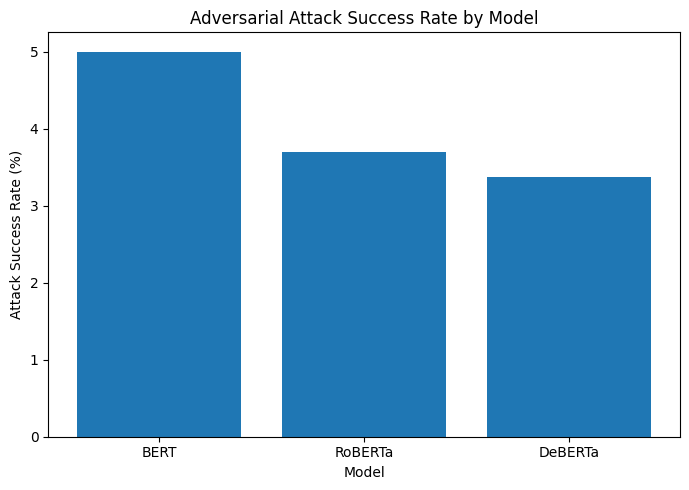

In [137]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    table_4_2["Model"],
    table_4_2["ASR (%)"]
)

plt.xlabel("Model")
plt.ylabel("Attack Success Rate (%)")
plt.title("Adversarial Attack Success Rate by Model")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FINAL_XAI_DIR,
        "figure_4_1_attack_success_rate.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

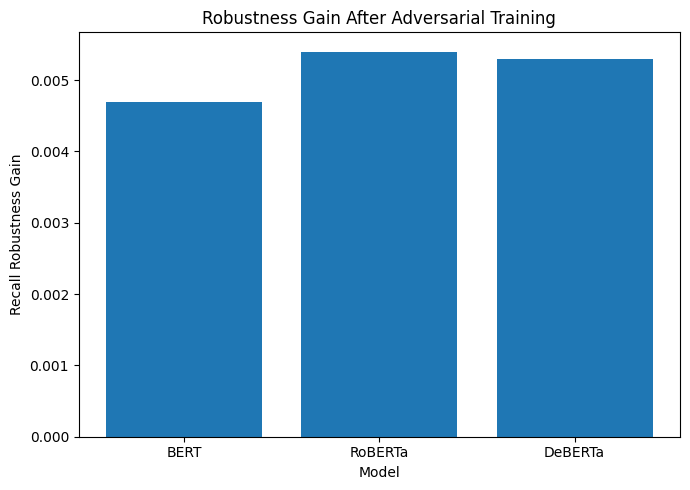

In [138]:
plt.figure(figsize=(7, 5))

plt.bar(
    table_4_3["Model"],
    table_4_3["Robustness Gain"]
)

plt.xlabel("Model")
plt.ylabel("Recall Robustness Gain")
plt.title("Robustness Gain After Adversarial Training")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FINAL_XAI_DIR,
        "figure_4_2_robustness_gain.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [139]:
import os

PROJECT_DIR = "/content/drive/MyDrive/phishing_project"

RESULT_DIR = os.path.join(
    PROJECT_DIR,
    "dissertation_results"
)

TABLE_DIR = os.path.join(
    RESULT_DIR,
    "tables"
)

FIGURE_DIR = os.path.join(
    RESULT_DIR,
    "figures"
)

APPENDIX_DIR = os.path.join(
    RESULT_DIR,
    "appendix"
)

CHAPTER4_DIR = os.path.join(
    RESULT_DIR,
    "chapter4"
)

for folder in [
    RESULT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    APPENDIX_DIR,
    CHAPTER4_DIR,
]:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [140]:
table_4_1.to_csv(
    os.path.join(TABLE_DIR, "table_4_1_baseline_performance.csv"),
    index=False
)

table_4_2.to_csv(
    os.path.join(TABLE_DIR, "table_4_2_attack_summary.csv"),
    index=False
)

table_4_3.to_csv(
    os.path.join(TABLE_DIR, "table_4_3_adversarial_training.csv"),
    index=False
)

table_4_4.to_csv(
    os.path.join(TABLE_DIR, "table_4_4_xai_summary.csv"),
    index=False
)

ig_convergence_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "integrated_gradients_convergence_summary.csv"
    ),
    index=False
)

print("Summary tables saved.")

Summary tables saved.


In [141]:
bert_shap_comparison.to_csv(
    os.path.join(
        TABLE_DIR,
        "table_4_5_bert_shap_changes.csv"
    ),
    index=False
)

bert_ig_comparison.to_csv(
    os.path.join(
        TABLE_DIR,
        "table_4_6_bert_ig_changes.csv"
    ),
    index=False
)

roberta_lime_comparison.to_csv(
    os.path.join(
        TABLE_DIR,
        "table_4_7_roberta_lime_changes.csv"
    ),
    index=False
)

deberta_lime_comparison.to_csv(
    os.path.join(
        TABLE_DIR,
        "table_4_8_deberta_lime_changes.csv"
    ),
    index=False
)

deberta_ig_comparison.to_csv(
    os.path.join(
        TABLE_DIR,
        "table_4_9_deberta_ig_changes.csv"
    ),
    index=False
)

print("Explanation tables saved.")

Explanation tables saved.


In [142]:
import shutil
import glob

source = os.path.join(
    PROJECT_DIR,
    "phase4_xai"
)

html_files = glob.glob(
    source + "/**/*.html",
    recursive=True
)

for f in html_files:
    shutil.copy(
        f,
        APPENDIX_DIR
    )

print("HTML explanation files copied.")

HTML explanation files copied.


In [143]:
csv_files = glob.glob(
    source + "/**/*.csv",
    recursive=True
)

for f in csv_files:
    shutil.copy(
        f,
        APPENDIX_DIR
    )

print("CSV explanation files copied.")

CSV explanation files copied.


In [144]:
with pd.ExcelWriter(
    os.path.join(
        CHAPTER4_DIR,
        "chapter4_tables.xlsx"
    )
) as writer:

    table_4_1.to_excel(
        writer,
        sheet_name="Baseline",
        index=False
    )

    table_4_2.to_excel(
        writer,
        sheet_name="Attack",
        index=False
    )

    table_4_3.to_excel(
        writer,
        sheet_name="Defense",
        index=False
    )

    table_4_4.to_excel(
        writer,
        sheet_name="XAI",
        index=False
    )

    ig_convergence_summary.to_excel(
        writer,
        sheet_name="IG",
        index=False
    )

print("Excel workbook saved.")

Excel workbook saved.


In [145]:
for root, dirs, files in os.walk(RESULT_DIR):
    print(root)
    for f in sorted(files):
        print("   ", f)

/content/drive/MyDrive/phishing_project/dissertation_results
/content/drive/MyDrive/phishing_project/dissertation_results/tables
    integrated_gradients_convergence_summary.csv
    table_4_1_baseline_performance.csv
    table_4_2_attack_summary.csv
    table_4_3_adversarial_training.csv
    table_4_4_xai_summary.csv
    table_4_5_bert_shap_changes.csv
    table_4_6_bert_ig_changes.csv
    table_4_7_roberta_lime_changes.csv
    table_4_8_deberta_lime_changes.csv
    table_4_9_deberta_ig_changes.csv
/content/drive/MyDrive/phishing_project/dissertation_results/figures
/content/drive/MyDrive/phishing_project/dissertation_results/appendix
    adversarial_ig.csv
    adversarial_modified.csv
    adversarial_modified.html
    adversarial_modified_shap.csv
    adversarial_original.csv
    adversarial_original.html
    adversarial_original_shap.csv
    bert_adversarial_lime.csv
    bert_adversarial_lime.html
    bert_adversarial_original_lime.csv
    bert_adversarial_original_lime.html
    bert

In [147]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

FIGURE_DIR = os.path.join(
    PROJECT_DIR,
    "dissertation_results",
    "figures"
)

os.makedirs(FIGURE_DIR, exist_ok=True)

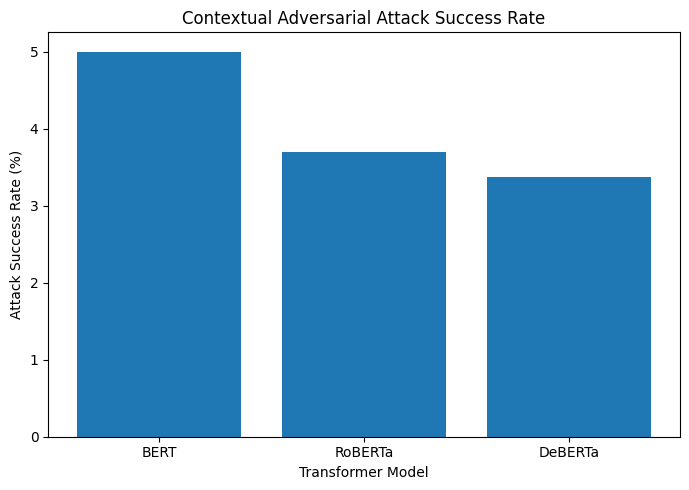

In [148]:
plt.figure(figsize=(7, 5))

plt.bar(
    table_4_2["Model"],
    table_4_2["ASR (%)"]
)

plt.xlabel("Transformer Model")
plt.ylabel("Attack Success Rate (%)")
plt.title("Contextual Adversarial Attack Success Rate")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_1_attack_success_rate.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

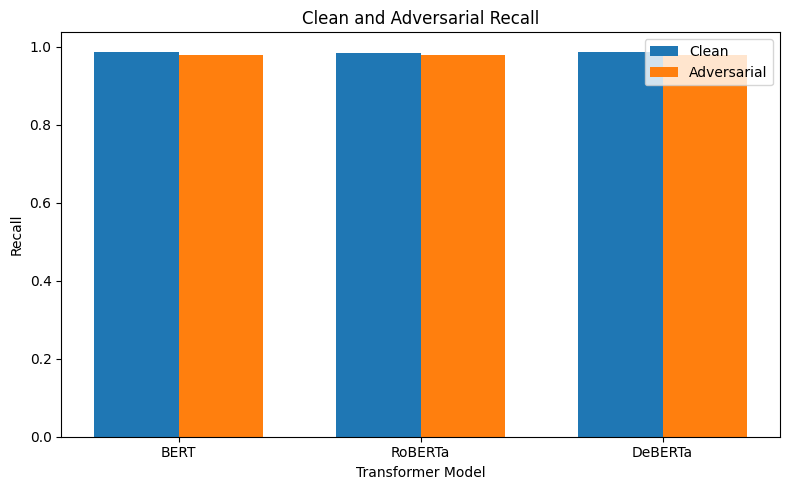

In [149]:
plt.figure(figsize=(8, 5))

x = np.arange(
    len(table_4_1["Model"])
)

width = 0.35

plt.bar(
    x - width/2,
    table_4_1["Clean Recall"],
    width,
    label="Clean"
)

plt.bar(
    x + width/2,
    table_4_1["Adversarial Recall"],
    width,
    label="Adversarial"
)

plt.xticks(
    x,
    table_4_1["Model"]
)

plt.xlabel("Transformer Model")
plt.ylabel("Recall")
plt.title("Clean and Adversarial Recall")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_2_clean_vs_adversarial_recall.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

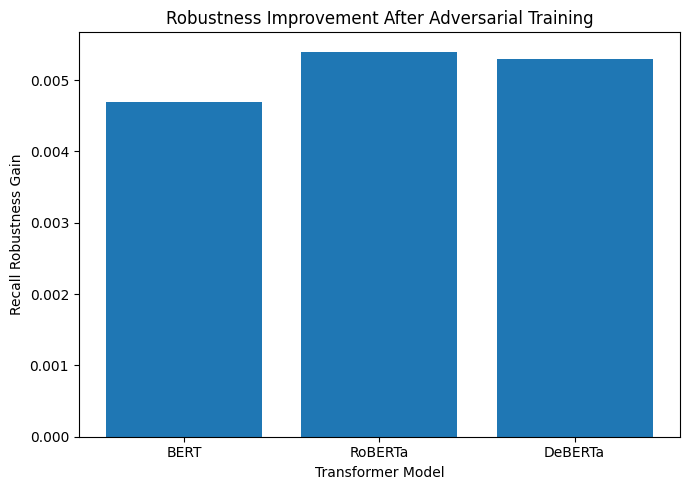

In [150]:
plt.figure(figsize=(7, 5))

plt.bar(
    table_4_3["Model"],
    table_4_3["Robustness Gain"]
)

plt.xlabel("Transformer Model")
plt.ylabel("Recall Robustness Gain")
plt.title(
    "Robustness Improvement After Adversarial Training"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_3_robustness_gain.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

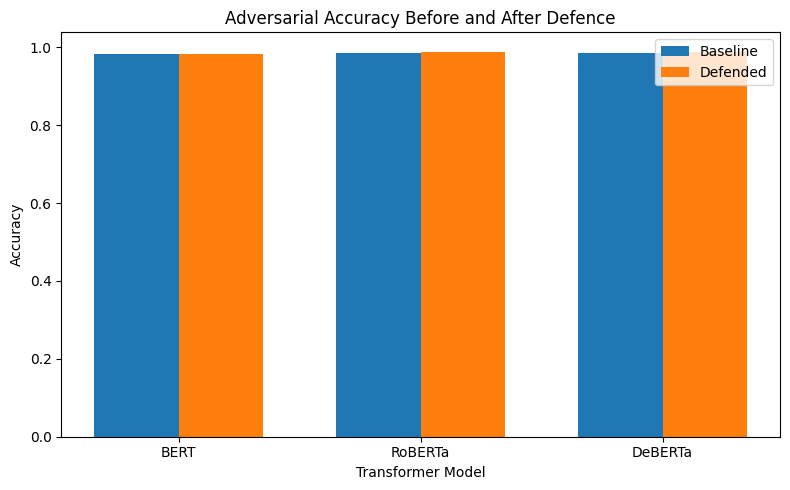

In [151]:
plt.figure(figsize=(8, 5))

x = np.arange(
    len(table_4_3["Model"])
)

width = 0.35

plt.bar(
    x - width/2,
    table_4_3[
        "Baseline Adversarial Accuracy"
    ],
    width,
    label="Baseline"
)

plt.bar(
    x + width/2,
    table_4_3[
        "Defended Adversarial Accuracy"
    ],
    width,
    label="Defended"
)

plt.xticks(
    x,
    table_4_3["Model"]
)

plt.xlabel("Transformer Model")
plt.ylabel("Accuracy")
plt.title(
    "Adversarial Accuracy Before and After Defence"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_4_defended_adversarial_accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

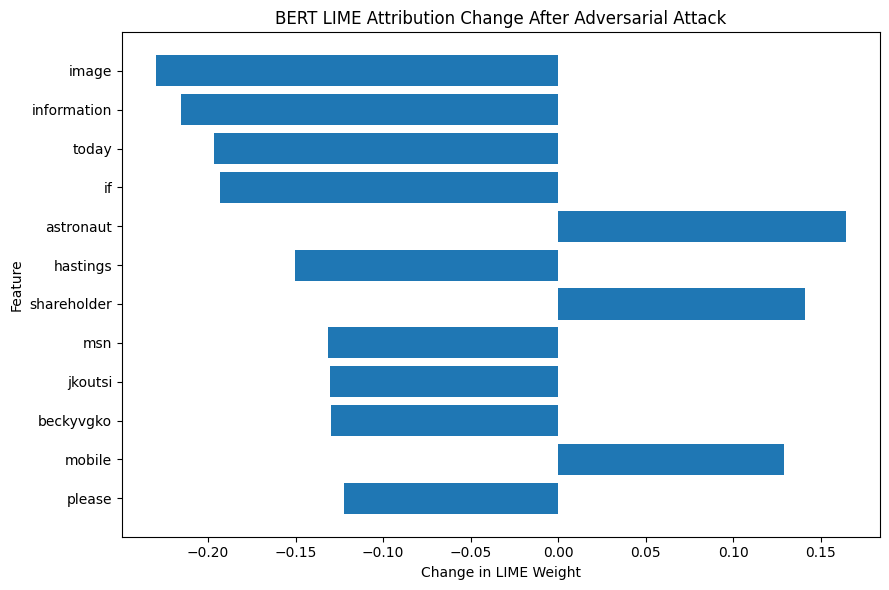

In [152]:
bert_lime_plot = (
    bert_lime_comparison
    .head(12)
    .sort_values(
        "abs_change",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    bert_lime_plot["feature"],
    bert_lime_plot["weight_change"]
)

plt.xlabel("Change in LIME Weight")
plt.ylabel("Feature")
plt.title(
    "BERT LIME Attribution Change After Adversarial Attack"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_5_bert_lime_change.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [154]:
bert_shap_plot = (
    bert_shap_clean_comparison
    .head(12)
    .sort_values(
        "abs_change",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    bert_shap_plot["token"],
    bert_shap_plot["shap_change"]
)

plt.xlabel("Change in SHAP Attribution")
plt.ylabel("Token")
plt.title(
    "BERT SHAP Attribution Change After Adversarial Attack"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_6_bert_shap_change.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'bert_shap_clean_comparison' is not defined

In [155]:
for var in sorted(globals()):
    if "shap" in var.lower():
        print(var)

BERT_SHAP_DIR
bert_shap_comparison
bert_shap_explainer
bert_shap_modified
bert_shap_modified_clean
bert_shap_modified_comp
bert_shap_modified_df
bert_shap_original
bert_shap_original_clean
bert_shap_original_comp
bert_shap_original_df
bert_shap_predict
clean_shap_tokens
shap


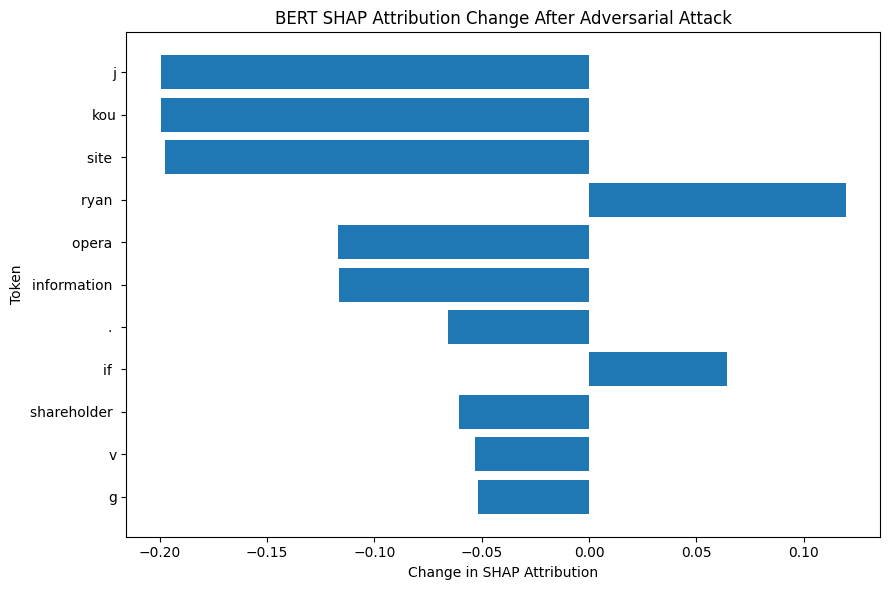

BERT SHAP figure saved.


In [156]:
bert_shap_plot = (
    bert_shap_comparison
    .head(12)
    .sort_values(
        "abs_change",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    bert_shap_plot["token"],
    bert_shap_plot["shap_change"]
)

plt.xlabel("Change in SHAP Attribution")
plt.ylabel("Token")
plt.title(
    "BERT SHAP Attribution Change After Adversarial Attack"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_6_bert_shap_change.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("BERT SHAP figure saved.")

In [157]:
print(
    os.path.exists(
        os.path.join(
            FIGURE_DIR,
            "figure_4_6_bert_shap_change.png"
        )
    )
)

True


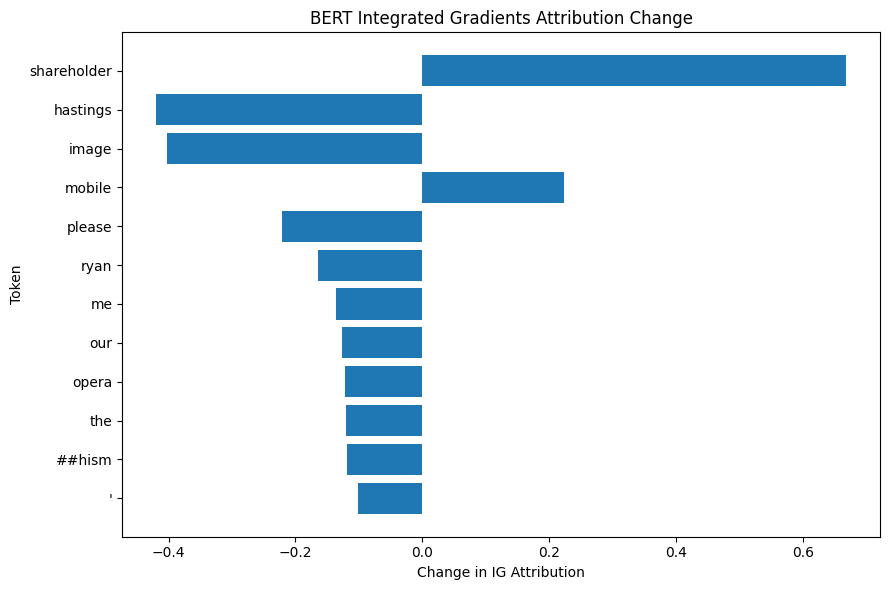

In [158]:
bert_ig_plot = (
    bert_ig_comparison
    .head(12)
    .sort_values(
        "abs_change",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    bert_ig_plot["token"],
    bert_ig_plot["ig_change"]
)

plt.xlabel("Change in IG Attribution")
plt.ylabel("Token")
plt.title(
    "BERT Integrated Gradients Attribution Change"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_7_bert_integrated_gradients.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

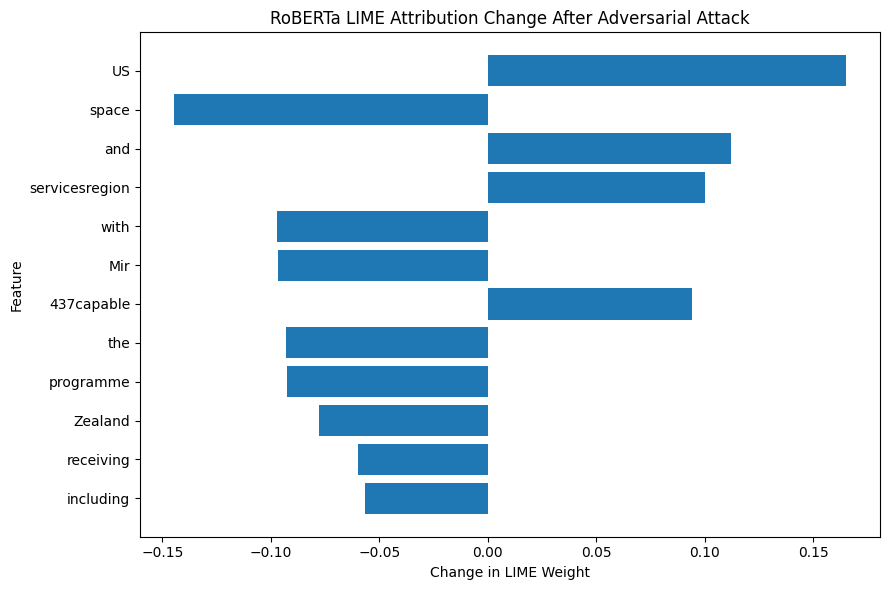

In [159]:
roberta_lime_plot = (
    roberta_lime_comparison
    .head(12)
    .sort_values(
        "abs_change",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    roberta_lime_plot["feature"],
    roberta_lime_plot["weight_change"]
)

plt.xlabel("Change in LIME Weight")
plt.ylabel("Feature")
plt.title(
    "RoBERTa LIME Attribution Change After Adversarial Attack"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_8_roberta_lime_change.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

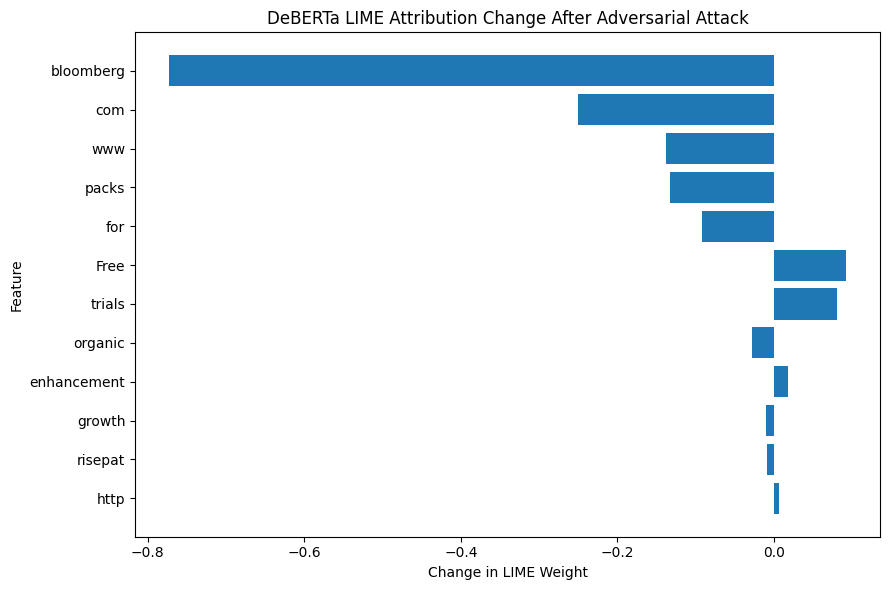

In [160]:
deberta_lime_plot = (
    deberta_lime_comparison
    .head(12)
    .sort_values(
        "abs_change",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    deberta_lime_plot["feature"],
    deberta_lime_plot["weight_change"]
)

plt.xlabel("Change in LIME Weight")
plt.ylabel("Feature")
plt.title(
    "DeBERTa LIME Attribution Change After Adversarial Attack"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_9_deberta_lime_change.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [161]:
import shutil

SOURCE_XAI = os.path.join(
    PROJECT_DIR,
    "phase4_xai"
)

SAFE_APPENDIX = os.path.join(
    PROJECT_DIR,
    "dissertation_results",
    "appendix",
    "phase4_xai_full"
)

if os.path.exists(SAFE_APPENDIX):
    shutil.rmtree(SAFE_APPENDIX)

shutil.copytree(
    SOURCE_XAI,
    SAFE_APPENDIX
)

print(
    "Full Phase 4 directory copied safely:"
)

print(SAFE_APPENDIX)

Full Phase 4 directory copied safely:
/content/drive/MyDrive/phishing_project/dissertation_results/appendix/phase4_xai_full


In [162]:
print("=" * 70)
print("TABLES")
print("=" * 70)

for f in sorted(
    os.listdir(TABLE_DIR)
):
    print(f)

print("\n" + "=" * 70)
print("FIGURES")
print("=" * 70)

for f in sorted(
    os.listdir(FIGURE_DIR)
):
    print(f)

print("\nTotal tables:",
      len(os.listdir(TABLE_DIR)))

print("Total figures:",
      len(os.listdir(FIGURE_DIR)))

TABLES
integrated_gradients_convergence_summary.csv
table_4_1_baseline_performance.csv
table_4_2_attack_summary.csv
table_4_3_adversarial_training.csv
table_4_4_xai_summary.csv
table_4_5_bert_shap_changes.csv
table_4_6_bert_ig_changes.csv
table_4_7_roberta_lime_changes.csv
table_4_8_deberta_lime_changes.csv
table_4_9_deberta_ig_changes.csv

FIGURES
figure_4_1_attack_success_rate.png
figure_4_2_clean_vs_adversarial_recall.png
figure_4_3_robustness_gain.png
figure_4_4_defended_adversarial_accuracy.png
figure_4_5_bert_lime_change.png
figure_4_6_bert_shap_change.png
figure_4_7_bert_integrated_gradients.png
figure_4_8_roberta_lime_change.png
figure_4_9_deberta_lime_change.png

Total tables: 10
Total figures: 9


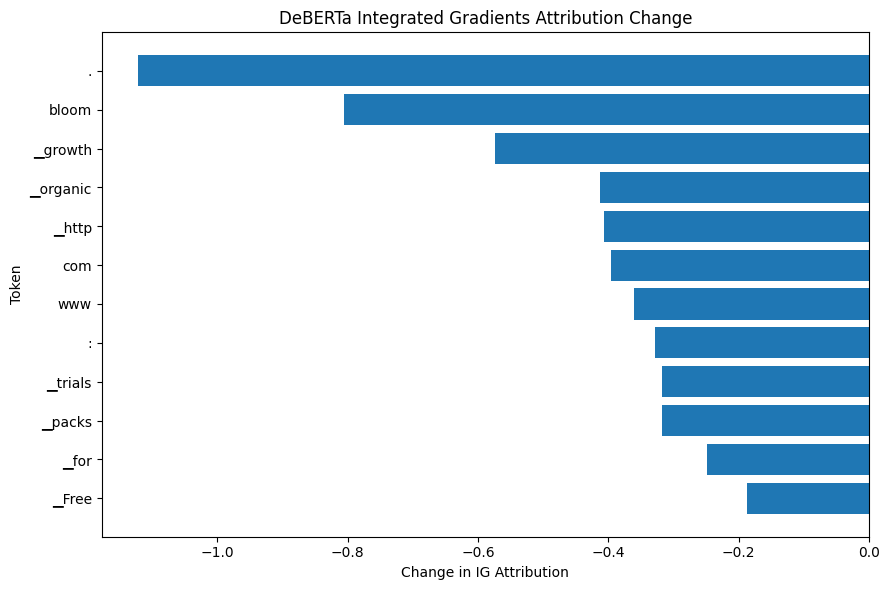

DeBERTa IG figure saved.


In [163]:
deberta_ig_plot = (
    deberta_ig_comparison
    .head(12)
    .sort_values(
        "abs_change",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    deberta_ig_plot["token"],
    deberta_ig_plot["ig_change"]
)

plt.xlabel("Change in IG Attribution")
plt.ylabel("Token")
plt.title(
    "DeBERTa Integrated Gradients Attribution Change"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "figure_4_10_deberta_integrated_gradients.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("DeBERTa IG figure saved.")

In [164]:
print(
    os.path.exists(
        os.path.join(
            FIGURE_DIR,
            "figure_4_10_deberta_integrated_gradients.png"
        )
    )
)

True


In [165]:
print("=" * 70)
print("TABLES")
print("=" * 70)

for f in sorted(os.listdir(TABLE_DIR)):
    print(f)

print("\n" + "=" * 70)
print("FIGURES")
print("=" * 70)

for f in sorted(os.listdir(FIGURE_DIR)):
    print(f)

print("\nTotal tables:", len(os.listdir(TABLE_DIR)))
print("Total figures:", len(os.listdir(FIGURE_DIR)))

TABLES
integrated_gradients_convergence_summary.csv
table_4_1_baseline_performance.csv
table_4_2_attack_summary.csv
table_4_3_adversarial_training.csv
table_4_4_xai_summary.csv
table_4_5_bert_shap_changes.csv
table_4_6_bert_ig_changes.csv
table_4_7_roberta_lime_changes.csv
table_4_8_deberta_lime_changes.csv
table_4_9_deberta_ig_changes.csv

FIGURES
figure_4_10_deberta_integrated_gradients.png
figure_4_1_attack_success_rate.png
figure_4_2_clean_vs_adversarial_recall.png
figure_4_3_robustness_gain.png
figure_4_4_defended_adversarial_accuracy.png
figure_4_5_bert_lime_change.png
figure_4_6_bert_shap_change.png
figure_4_7_bert_integrated_gradients.png
figure_4_8_roberta_lime_change.png
figure_4_9_deberta_lime_change.png

Total tables: 10
Total figures: 10


In [166]:
import shutil
import os

PROJECT_DIR = "/content/drive/MyDrive/phishing_project"

RESULT_DIR = os.path.join(
    PROJECT_DIR,
    "dissertation_results"
)

archive_path = shutil.make_archive(
    os.path.join(PROJECT_DIR, "dissertation_results_backup"),
    "zip",
    RESULT_DIR
)

print("Backup created:")
print(archive_path)

Backup created:
/content/drive/MyDrive/phishing_project/dissertation_results_backup.zip
